# An Attribution-Controlled Study of Feature Priors in LLM-Guided Grammatical Evolution

Main experiment notebook. Running every cell top to bottom regenerates the complete
experiment folder `results/experiments/<run_id>/`: 8 checkpoints, 25 summary tables,
8 per-seed tables, 16 figures (PNG + PDF), the 25-sheet Excel workbook, logs and manifest —
the same inventory as the reference run `20260831_202209`.

Set `SMOKE = True` in the first cell for a 3-seed end-to-end check (~10 min, written to
`results/_smoke`); `False` is the full 30-seed run (~3.5 h on one core, of which the
compute-equivalence study is about an hour). Every stage is
checkpointed per (dataset, arm, seed), so re-running a cell after an interruption continues
where it stopped. Set `RESUME_RUN_ID` to continue an existing run folder.

In [1]:
SMOKE = False           # True: 3 seeds, quick check
RESUME_RUN_ID = None    # e.g. "20260909_164325" to continue an existing run folder

import json, os, platform, sys, time, warnings
from datetime import datetime
from pathlib import Path

# locate the project root (the folder that contains geprior/), from notebooks/ or the root
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "geprior" / "__init__.py").exists())
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
warnings.filterwarnings("ignore", category=FutureWarning)

from geprior import config, datasets, priors, grammar, engine, baselines, experiments
from geprior import statistics as st, figures as fg

KEYS = ["wbcd", "pima", "cleveland", "heart_failure"]


LABELS = {"wbcd": "WBCD", "pima": "Pima", "cleveland": "Cleveland",
          "heart_failure": "Heart Failure"}


ARMS = list(config.SELECTION_ARMS)


CONSTRUCTION = list(config.CONSTRUCTION_ARMS)

## 0. Experiment folder

Everything below is written into one timestamped folder. `config.FIGURES_DIR` is redirected
so the package's own figure functions save into `plots/` alongside the figure pack.

In [2]:
class Tee:
    """Mirror stdout/stderr into logs/console.txt."""

    def __init__(self, stream, path: Path):
        self.stream, self.file = stream, open(path, "a", encoding="utf-8")

    def write(self, text):
        self.stream.write(text)
        self.file.write(text)
        self.file.flush()

    def flush(self):
        self.stream.flush()
        self.file.flush()

    def __getattr__(self, name):          # e.g. set_parent/encoding of a Jupyter OutStream
        return getattr(self.stream, name)


def tee(stream, path: Path):
    """Wrap the current stream (works in a terminal and inside a Jupyter kernel);
    a stream that is already a Tee is re-pointed rather than wrapped twice."""
    if isinstance(stream, Tee):
        stream.file.close()
        stream = stream.stream
    return Tee(stream, path)


class Run:
    """One experiment folder and the tables it accumulates."""

    def __init__(self, folder: Path, smoke: bool):
        self.folder, self.smoke = folder, smoke
        for sub in ("checkpoints", "csv/per_seed", "plots", "excel", "logs"):
            (folder / sub).mkdir(parents=True, exist_ok=True)
        self.tables: dict[str, tuple[pd.DataFrame, bool]] = {}   # name -> (frame, keep index)

    def ckpt(self, name: str) -> Path:
        return self.folder / "checkpoints" / name

    def table(self, name: str, frame: pd.DataFrame, index: bool = False) -> pd.DataFrame:
        frame.to_csv(self.folder / "csv" / f"{name}.csv", index=index)
        self.tables[name] = (frame, index)
        return frame

    def log(self, name: str, text: str) -> None:
        (self.folder / "logs" / name).write_text(text, encoding="utf-8")


def environment_text(run_id: str, started: str, smoke: bool) -> str:
    import importlib.metadata as md
    lines = [f"run_id: {run_id}", f"started: {started}", f"smoke_mode: {smoke}",
             f"repository_root: {ROOT}", f"python: {platform.python_version()} ({sys.executable})",
             f"platform: {platform.platform()}", ""]
    for pkg in ("deap", "matplotlib", "numpy", "openpyxl", "pandas", "scikit-learn", "scipy", "xgboost"):
        try:
            lines.append(f"{pkg}=={md.version(pkg)}")
        except md.PackageNotFoundError:
            lines.append(f"{pkg}==(not installed)")
    return "\n".join(lines) + "\n"


N_SEEDS = 3 if SMOKE else config.N_SEEDS
ABLATION_SEEDS = 3 if SMOKE else config.ABLATION_SEEDS
SEEDS = list(range(1, N_SEEDS + 1))

base_dir = config.RESULTS_DIR / ("_smoke" if SMOKE else "experiments")
base_dir.mkdir(parents=True, exist_ok=True)
RUN_ID = RESUME_RUN_ID or datetime.now().strftime("%Y%m%d_%H%M%S")
STARTED = datetime.now().strftime("%Y-%m-%dT%H:%M:%S")
run = Run(base_dir / RUN_ID, SMOKE)
config.FIGURES_DIR = run.folder / "plots"
sys.stdout = tee(sys.stdout, run.folder / "logs" / "console.txt")
sys.stderr = tee(sys.stderr, run.folder / "logs" / "console.txt")
run.log("environment.txt", environment_text(RUN_ID, STARTED, SMOKE))
run.log("config_snapshot.txt", config.summary().split(" soft_multiplier")[0] + "\n")
T0 = time.time()
print(f"experiment folder: {run.folder}")
r = {}                                  # results shared between the cells below

experiment folder: C:\Users\awwal\OneDrive\Desktop\ge_prior_attribution_local\ge_prior_attribution_local\results\experiments\20260909_233017


## 1. Datasets

Four public clinical datasets spanning a range of difficulty. `budget` is the fixed
selection budget K shared by every selection-prior arm.

In [3]:
display(run.table("datasets", datasets.describe(), index=True))

,key,dataset,samples,features,budget,positive_rate
0,wbcd,WBCD,569,30,8,0.373
1,pima,Pima,768,8,4,0.349
2,cleveland,Cleveland,303,13,6,0.545
3,heart_failure,Heart Failure,299,11,5,0.321


## 2. The knowledge prior

The prior is an LLM output reasoning over feature names alone, with no access to labels or
data statistics. `LLM_BACKEND = "cached"` replays a provenance-documented response.

In [4]:
prov = (f"backend: {priors.LLM.backend} | live: {priors.LLM.is_live}\n"
        f"provenance: {priors.CACHED_LLM_PRIOR['provenance']}\n")
print(prov, end="")
run.log("llm_prior_provenance.txt", prov)
rows = []
for key in KEYS:
    split = datasets.prepare_split(key, seed=1)
    idx = priors.selection_indices("llm", split.X_train, split.y_train,
                                   split.features, split.budget, 1, key)
    print(f"  {key:14s}", [split.features[i] for i in idx])
    rows.append(dict(dataset=key, budget_K=split.budget,
                     selected_features=", ".join(str(split.features[i]) for i in idx)))
run.table("llm_prior_selections", pd.DataFrame(rows))

backend: cached | live: False
provenance: {'model': 'Claude (Anthropic)', 'method': 'clinical reasoning over feature names; no access to labels or statistics', 'temperature': 0.0}
  wbcd           [np.str_('mean concavity'), np.str_('mean concave points'), np.str_('worst radius'), np.str_('worst perimeter'), np.str_('worst area'), np.str_('worst compactness'), np.str_('worst concavity'), np.str_('worst concave points')]
  pima           ['Glucose', 'BMI', 'DiabetesPedigreeFunction', 'Age']
  cleveland      ['cp', 'thalach', 'exang', 'oldpeak', 'ca', 'thal']
  heart_failure  ['age', 'anaemia', 'creatinine_phosphokinase', 'ejection_fraction', 'serum_creatinine']


,dataset,budget_K,selected_features
0,wbcd,8,"mean concavity, mean concave points, worst rad..."
1,pima,4,"Glucose, BMI, DiabetesPedigreeFunction, Age"
2,cleveland,6,"cp, thalach, exang, oldpeak, ca, thal"
3,heart_failure,5,"age, anaemia, creatinine_phosphokinase, ejecti..."


## 3. Grammar

A prior is injected purely by restricting the terminal rule `<v>`; every other production is
identical across arms.

In [5]:
split = datasets.prepare_split("pima", seed=1)
idx = priors.selection_indices("llm", split.X_train, split.y_train,
                               split.features, split.budget, 1, "pima")
text = grammar.weighted_grammar_text(idx)
print(text)
run.log("weighted_grammar_pima.txt", text + "\n")

<e> ::= <t> | add(<e>,<t>) | sub(<e>,<t>)
<t> ::= mul(<w>,<v>) | mul(<w>,<nl>)
<nl> ::= mul(<v>,<v>) | pdiv(<v>,<v>) | psqrt(<v>) | plog(<v>)
<v> ::= x[:,1] | x[:,5] | x[:,6] | x[:,7]
<w> ::= 0.1 | 0.25 | 0.5 | 0.75 | 1.0 | 1.5 | 2.0 | 3.0 | 5.0



## 4. Baselines

Five standard classifiers on the full feature set, fitted on the identical per-seed splits as
every GE condition.

In [6]:
base = baselines.run_baselines(seeds=SEEDS, checkpoint=run.ckpt("baselines.csv"))
r["base"] = base
base_tbl = base.groupby(["model", "dataset"])["roc_auc"].median().unstack("dataset")[KEYS].round(3)
run.table("baseline_medians", base_tbl, index=True)

  baselines: wbcd complete (30s)


c:\Users\awwal\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (600) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\awwal\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (600) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\awwal\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (600) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\awwal\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (600) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\awwal\anaconda3\Lib\site-packages\sklearn\neural_network\_multi

  baselines: pima complete (86s)


c:\Users\awwal\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (600) reached and the optimization hasn't converged yet.
  warnings.warn(


  baselines: cleveland complete (128s)


c:\Users\awwal\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (600) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\awwal\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (600) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\awwal\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (600) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\awwal\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (600) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\awwal\anaconda3\Lib\site-packages\sklearn\neural_network\_multi

  baselines: heart_failure complete (162s)


dataset,wbcd,pima,cleveland,heart_failure
model,,,,
Logistic Regression,0.997,0.838,0.907,0.769
MLP,0.995,0.771,0.884,0.708
Random Forest,0.991,0.828,0.903,0.783
SVM (RBF),0.997,0.826,0.904,0.778
XGBoost,0.994,0.785,0.870,0.711


### Black-box feature-engineering comparator

A CAAFE-style pipeline (Hollmann et al., 2023): LLM-proposed features added greedily under a
cross-validated acceptance gate, feeding a logistic regression.

In [7]:
blackbox = baselines.run_blackbox_baseline(seeds=SEEDS, checkpoint=run.ckpt("blackbox_fe.csv"))
r["blackbox"] = blackbox
bb = blackbox.groupby("dataset")["roc_auc"].median().reindex(KEYS).round(3)
bb = bb.rename("median_roc_auc").rename_axis("dataset").reset_index()
run.table("blackbox_medians", bb)

  black-box FE: wbcd complete (3s)
  black-box FE: pima complete (6s)
  black-box FE: cleveland complete (8s)
  black-box FE: heart_failure complete (10s)


,dataset,median_roc_auc
0,wbcd,0.997
1,pima,0.838
2,cleveland,0.906
3,heart_failure,0.770


## 5. Selection study

Noise, data and knowledge as sources of a feature prior, at matched budget K.

In [8]:
selection = experiments.run_selection_study(seeds=SEEDS, n_restarts=1,
                                            checkpoint=run.ckpt("selection.csv"))
r["selection"] = selection
run.table("selection_medians", st.median_table(selection, ARMS, dataset_keys=KEYS).round(3), index=True)

  selection: wbcd complete (313s)
  selection: pima complete (707s)
  selection: cleveland complete (1029s)
  selection: heart_failure complete (1307s)


arm,none,random,mi,corr,llm
dataset,,,,,
wbcd,0.991,0.987,0.987,0.987,0.988
pima,0.828,0.775,0.828,0.827,0.835
cleveland,0.865,0.830,0.868,0.859,0.877
heart_failure,0.752,0.669,0.771,0.768,0.785


## 6. Construction study

GE runs unrestricted over the raw feature set augmented with five engineered features.

In [9]:
construction = experiments.run_construction_study(seeds=SEEDS, checkpoint=run.ckpt("construction.csv"))
r["construction"] = construction
run.table("construction_medians",
          st.median_table(construction, CONSTRUCTION, dataset_keys=KEYS).round(3), index=True)

  construction: wbcd complete (141s)
  construction: pima complete (305s)
  construction: cleveland complete (487s)
  construction: heart_failure complete (641s)


arm,raw,random,llm
dataset,,,
wbcd,0.991,0.991,0.990
pima,0.828,0.826,0.830
cleveland,0.865,0.854,0.858
heart_failure,0.752,0.747,0.747


## 7. Selection-prior figure

In [10]:
fig_tbl = fg.plot_arm_medians(selection, ARMS, KEYS, "selection_by_dataset",
                              title="Selection-prior arms by dataset (median over seeds)").round(3)
run.table("selection_figure_arm_medians", fig_tbl, index=True)

arm,none,random,mi,corr,llm
dataset,,,,,
wbcd,0.991,0.987,0.987,0.987,0.988
pima,0.828,0.775,0.828,0.827,0.835
cleveland,0.865,0.830,0.868,0.859,0.877
heart_failure,0.752,0.669,0.771,0.768,0.785


## 8. Statistical protocol

Per-dataset Friedman tests over the seed-paired resamples carry the inference; the mean rank
across datasets is descriptive only. Then the pre-registered contrasts C1–C3, Holm-corrected
within each dataset, with Cliff's delta.

In [11]:
friedman, ranks = st.per_dataset_friedman(selection, ARMS, dataset_keys=KEYS)
friedman = friedman.round(4)
display(friedman)
print("mean rank across datasets (descriptive only):")
print(ranks.mean(axis=0).round(2).to_string())
run.table("friedman_tests", friedman, index=True)
ranks = ranks.reindex(KEYS)
run.table("arm_ranks", ranks.round(2), index=True)
fg.plot_rank_heatmap(ranks)

contrasts = st.preregistered_contrasts(selection, construction, dataset_keys=KEYS).round(4)
r["friedman"], r["contrasts"] = friedman, contrasts
run.table("preregistered_contrasts", contrasts, index=True)

,dataset,n_seeds,friedman_chi2,p,none,random,mi,corr,llm
0,wbcd,30,13.33,0.0098,2.12,3.45,3.28,3.02,3.13
1,pima,30,52.08,0.0000,3.07,4.75,2.48,2.60,2.10
2,cleveland,30,23.57,0.0001,2.90,3.97,2.62,3.35,2.17
3,heart_failure,30,32.18,0.0000,3.37,4.23,2.62,2.63,2.15


mean rank across datasets (descriptive only):
arm
none      2.86
random    4.10
mi        2.75
corr      2.90
llm       2.39


,dataset,contrast_id,study,contrast,median_diff,cliffs_delta,magnitude,p_raw,p_holm,significant,n
0,wbcd,C1,selection,llm vs random,0.0016,0.0678,negligible,0.2801,0.8403,False,30
1,wbcd,C2,selection,llm vs mi,0.0006,0.0333,negligible,0.7000,1.0000,False,30
2,wbcd,C3,construction,llm vs random,0.0009,-0.0067,negligible,0.6583,1.0000,False,30
3,pima,C1,selection,llm vs random,0.0531,0.7856,large,0.0000,0.0000,True,30
4,pima,C2,selection,llm vs mi,0.0021,0.1678,small,0.2494,0.4343,False,30
5,pima,C3,construction,llm vs random,0.0020,0.1511,small,0.2172,0.4343,False,30
6,cleveland,C1,selection,llm vs random,0.0535,0.5878,large,0.0000,0.0000,True,30
7,cleveland,C2,selection,llm vs mi,0.0061,0.1944,small,0.0306,0.0612,False,30
8,cleveland,C3,construction,llm vs random,0.0006,0.1056,negligible,0.6554,0.6554,False,30
9,heart_failure,C1,selection,llm vs random,0.0793,0.6467,large,0.0000,0.0000,True,30


## 9. Structural diagnostics

In [12]:
diag = st.structural_diagnostics(selection, ARMS)
display(run.table("structural_diagnostics", diag, index=True))
fg.plot_length_vs_generalisation(selection, ARMS)

,effective_length,structural_diversity,phenotype_coverage,invalids,depth,generalisation_gap,test_roc_auc
arm,,,,,,,
none,32.0,0.893,0.462,0.0,10.0,0.012,0.841
random,33.0,0.885,0.800,0.0,10.0,0.024,0.797
mi,33.0,0.885,0.800,0.0,10.0,0.013,0.845
corr,33.5,0.880,0.833,0.0,10.5,0.013,0.844
llm,35.0,0.895,0.854,0.0,11.0,0.011,0.853


## 10. What interpretability costs

A protocol-matched 5-restart GE ensemble alongside the single rule separates the cost of the
symbolic representation from the cost of comparing one model to an ensemble.

In [13]:
ensemble = experiments.run_selection_study(seeds=SEEDS, arms=["llm"], n_restarts=5,
                                           checkpoint=run.ckpt("ensemble.csv"))
r["ensemble"] = ensemble
comparison = pd.DataFrame({
    "GE rule (llm)": selection[selection.arm == "llm"].groupby("dataset")["test_roc_auc"].median(),
    "GE ensemble (llm)": ensemble.groupby("dataset")["ensemble_roc_auc"].median(),
    "Black-box FE": blackbox.groupby("dataset")["roc_auc"].median(),
    "Logistic Regression": base[base.model == "Logistic Regression"].groupby("dataset")["roc_auc"].median(),
}).reindex(KEYS)
r["comparison"] = comparison
fg.plot_interpretability_cost(comparison)
run.table("interpretability_cost", comparison.round(3), index=True)

  selection: wbcd complete (262s)
  selection: pima complete (571s)
  selection: cleveland complete (885s)
  selection: heart_failure complete (1175s)


,GE rule (llm),GE ensemble (llm),Black-box FE,Logistic Regression
dataset,,,,
wbcd,0.988,0.989,0.997,0.997
pima,0.835,0.840,0.838,0.838
cleveland,0.877,0.890,0.906,0.907
heart_failure,0.785,0.776,0.770,0.769


## 11. Configuration ablation

Each variant adds exactly one configuration choice to the one above it.

In [14]:
ablation = experiments.run_ablation(seeds=list(range(1, ABLATION_SEEDS + 1)),
                                    checkpoint=run.ckpt("ablation.csv"))
r["ablation"] = ablation
abl_auc = (ablation.groupby(["dataset", "variant"])["test_roc_auc"].median()
           .unstack("variant").reindex(KEYS).round(3))
abl_f1 = (ablation.groupby(["dataset", "variant"])["test_f1"].median()
          .unstack("variant").reindex(KEYS).round(3))
display(run.table("ablation_roc_auc", abl_auc, index=True))
display(run.table("ablation_f1", abl_f1, index=True))
fg.plot_configuration_ablation(ablation)

  ablation: wbcd complete (256s)
  ablation: pima complete (619s)
  ablation: cleveland complete (1051s)
  ablation: heart_failure complete (1405s)


variant,+ AUC objective,+ threshold calibration,+ validation selection,+ weighted grammar,Base
dataset,,,,,
wbcd,0.985,0.988,0.988,0.987,0.982
pima,0.826,0.835,0.835,0.834,0.821
cleveland,0.874,0.877,0.877,0.879,0.828
heart_failure,0.760,0.785,0.785,0.785,0.740


variant,+ AUC objective,+ threshold calibration,+ validation selection,+ weighted grammar,Base
dataset,,,,,
wbcd,0.908,0.922,0.913,0.926,0.911
pima,0.633,0.676,0.660,0.658,0.624
cleveland,0.812,0.820,0.795,0.798,0.804
heart_failure,0.573,0.611,0.545,0.544,0.588


variant,Base,+ AUC objective,+ weighted grammar,+ validation selection,+ threshold calibration
dataset,,,,,
cleveland,0.828293,0.873902,0.878902,0.877439,0.877439
heart_failure,0.739542,0.759751,0.785472,0.785472,0.785472
pima,0.820741,0.826255,0.834115,0.835391,0.835391
wbcd,0.981893,0.984886,0.986711,0.988026,0.988026


## 12. Compute-equivalence study

Can more search recover what the prior supplies? One traced search per (dataset, arm, seed)
runs the `none`, `mi` and `llm` arms to 160 generations (4x the base budget of 40) and is
model-selected as if it had been stopped at 40, 80 and 160. The per-generation validation
ROC-AUC of the training-fitness leader is written alongside, giving the search-progress
curves and the generations-to-match statistic. Contrast C6 (pre-registered) tests
`llm@40 > none@160`, paired on seed.


In [ ]:
BUDGETS = list(config.BUDGET_CHECKPOINTS)          # (40, 80, 160) generations
BUDGET_ARMS = list(config.BUDGET_ARMS)              # ("none", "mi", "llm")

budget = experiments.run_budget_study(seeds=SEEDS, checkpoint=run.ckpt("budget.csv"),
                                      curve_path=run.ckpt("budget_curves.csv"))
budget_curves = pd.read_csv(run.ckpt("budget_curves.csv"))
r["budget"], r["budget_curves"] = budget, budget_curves

# median test ROC-AUC by arm and generation checkpoint (flattened to arm@generations)
bud_tbl = st.budget_table(budget, KEYS)
bud_tbl.columns = [f"{arm}@{g}" for arm, g in bud_tbl.columns]
bud_tbl = bud_tbl[[f"{a}@{g}" for a in BUDGET_ARMS for g in BUDGETS if f"{a}@{g}" in bud_tbl.columns]]
display(run.table("budget_medians", bud_tbl.round(3), index=True))

# C6 and companions: llm at the base budget against none / mi at every budget
c6 = st.budget_contrasts(budget, KEYS).round(4)
c6["significant"] = c6["p_one_sided"] < config.ALPHA
display(run.table("budget_contrasts", c6))

# generations the no-prior (and data-prior) search needs to reach llm's base-budget level
g2m = st.generations_to_match(budget_curves).set_index("dataset").reindex(KEYS).reset_index()
g2m_mi = (st.generations_to_match(budget_curves, search_arm="mi")
          .set_index("dataset").reindex(KEYS).reset_index())
display(run.table("generations_to_match", g2m.round(2)))
run.table("generations_to_match_mi", g2m_mi.round(2))

# the two compute-equivalence figures: leader curves and test performance against budget
fg.plot_budget_curves(budget_curves, KEYS)
fg.plot_budget_bars(budget, KEYS)
print("saved figures: budget_curves and budget_scaling (PNG + PDF)")


## 13. Representative interpretable rules

The run whose test ROC-AUC is nearest that arm's **median**, not its best.

In [15]:
def representative_rule(df, key, arm="llm"):
    from geprior import datasets, engine
    sub = df[(df.dataset == key) & (df.arm == arm)].dropna(subset=["test_roc_auc"])
    target = sub["test_roc_auc"].median()
    row = sub.iloc[(sub["test_roc_auc"] - target).abs().argmin()]
    split = datasets.prepare_split(key, int(row["seed"]))
    return dict(dataset=key, seed=int(row["seed"]),
                roc_auc=round(row["test_roc_auc"], 3), f1=round(row["test_f1"], 3),
                effective_length=int(row["effective_length"]),
                rule=engine.readable_rule(row["phenotype"], split.features))


rows = []
for key in KEYS:
    rr = representative_rule(selection, key)
    rows.append(rr)
    print(f"\n{rr['dataset']}  AUC={rr['roc_auc']}  F1={rr['f1']}  len={rr['effective_length']}")
    print("  ", rr["rule"][:220])
run.table("representative_rules", pd.DataFrame(rows))


wbcd  AUC=0.988  F1=0.91  len=39
   add(add(add(add(add(add(add(mul(1.5,mean concave points),mul(1.0,mul(worst area,mean concavity))),mul(2.0,worst concave points)),mul(1.5,worst perimeter)),mul(3.0,worst area)),mul(1.5,plog(worst radius))),mul(1.5,mul(wor

pima  AUC=0.836  F1=0.591  len=55
   add(add(add(add(add(add(add(add(add(add(add(mul(2.0,DiabetesPedigreeFunction),mul(0.25,mul(DiabetesPedigreeFunction,BMI))),mul(1.5,Age)),mul(1.0,Glucose)),mul(1.0,BMI)),mul(1.5,Age)),mul(1.0,Glucose)),mul(3.0,BMI)),mul(0

cleveland  AUC=0.879  F1=0.821  len=39
   sub(add(sub(add(sub(add(sub(sub(mul(0.5,ca),mul(1.0,thal)),mul(1.5,plog(cp))),mul(1.0,cp)),mul(2.0,ca)),mul(0.5,thalach)),mul(0.1,psqrt(thal))),mul(0.25,thalach)),mul(3.0,psqrt(thal)))

heart_failure  AUC=0.783  F1=0.598  len=43
   add(add(add(sub(add(add(add(add(add(mul(3.0,serum_creatinine),mul(3.0,plog(ejection_fraction))),mul(0.5,serum_creatinine)),mul(1.5,psqrt(ejection_fraction))),mul(3.0,plog(age))),mul(0.5,creatinine_phosphokina

,dataset,seed,roc_auc,f1,effective_length,rule
0,wbcd,13,0.988,0.910,39,"add(add(add(add(add(add(add(mul(1.5,mean conca..."
1,pima,14,0.836,0.591,55,add(add(add(add(add(add(add(add(add(add(add(mu...
2,cleveland,3,0.879,0.821,39,"sub(add(sub(add(sub(add(sub(sub(mul(0.5,ca),mu..."
3,heart_failure,23,0.783,0.598,43,"add(add(add(sub(add(add(add(add(add(mul(3.0,se..."


## 14. Explainability check on WBCD

A surrogate explainer: feature importances of a random forest, as an independent check on
which features a conventional model considers important — not an explanation of the evolved
rule itself.

In [16]:
from sklearn.ensemble import RandomForestClassifier

rep = representative_rule(selection, "wbcd")
split = datasets.prepare_split("wbcd", rep["seed"])
row = selection[(selection.dataset == "wbcd") & (selection.arm == "llm")
                & (selection.seed == rep["seed"])].iloc[0]
scores = engine.phenotype_score(row["phenotype"], split.X_test)
fg.plot_confusion(split.y_test, (scores > row["threshold"]).astype(int),
                  "WBCD evolved rule, test partition", "wbcd_confusion")
forest = RandomForestClassifier(n_estimators=400,
                                random_state=config.GLOBAL_SEED).fit(split.X_train, split.y_train)
order = np.argsort(forest.feature_importances_)[::-1][:6]
top = [split.features[i] for i in order]
used = [split.features[i] for i in engine.used_feature_indices(row["phenotype"], split.n_features)]
print("random-forest surrogate, top-6 features:", top)
print("features referenced by the evolved rule:", used)
run.table("wbcd_explainability_features", pd.DataFrame([
    dict(source="random-forest surrogate (top-6)", features=", ".join(map(str, top))),
    dict(source="evolved rule", features=", ".join(map(str, used)))]))

random-forest surrogate, top-6 features: [np.str_('worst perimeter'), np.str_('worst area'), np.str_('worst concave points'), np.str_('mean concave points'), np.str_('mean concavity'), np.str_('worst radius')]
features referenced by the evolved rule: [np.str_('mean concavity'), np.str_('mean concave points'), np.str_('worst radius'), np.str_('worst perimeter'), np.str_('worst area'), np.str_('worst compactness'), np.str_('worst concave points')]


,source,features
0,random-forest surrogate (top-6),"worst perimeter, worst area, worst concave poi..."
1,evolved rule,"mean concavity, mean concave points, worst rad..."


## 15. Consolidated summary

In [17]:
def consolidated_summary(run: Run, r: dict):
    from geprior import statistics as st
    lines = []
    def show(title, obj):
        lines.append(f"=== {title} ===")
        lines.append(obj.to_string() if not isinstance(obj, str) else obj)
        lines.append("")
    show("baselines", r["base"].groupby(["model", "dataset"])["roc_auc"].median().unstack("dataset")[KEYS].round(3))
    show("selection arms (median test ROC-AUC)", st.median_table(r["selection"], ARMS, dataset_keys=KEYS).round(3))
    show("construction arms (median test ROC-AUC)", st.median_table(r["construction"], CONSTRUCTION, dataset_keys=KEYS).round(3))
    lines.append("=== per-dataset Friedman ===")
    lines.append(r["friedman"].round(4).to_string(index=False)); lines.append("")
    lines.append("=== pre-registered contrasts ===")
    lines.append(r["contrasts"].round(4).to_string(index=False)); lines.append("")
    show("structural diagnostics", st.structural_diagnostics(r["selection"], ARMS))
    show("interpretability cost", r["comparison"].round(3))
    if "budget" in r:
        bt = st.budget_table(r["budget"], KEYS)
        bt.columns = [f"{arm}@{g}" for arm, g in bt.columns]
        show("compute-equivalence (median test ROC-AUC, arm@generations)", bt.round(3))
        lines.append("=== C6 and companions: llm@base vs none/mi at each budget ===")
        lines.append(st.budget_contrasts(r["budget"], KEYS).round(4).to_string(index=False)); lines.append("")
        show("generations to match (none searching for llm@base level)",
             st.generations_to_match(r["budget_curves"]).set_index("dataset").reindex(KEYS).round(2))
    text = "\n".join(lines).rstrip("\n") + "\n"
    print(text, end="")
    run.log("consolidated_summary.txt", text)


consolidated_summary(run, r)

=== baselines ===
dataset               wbcd   pima  cleveland  heart_failure
model                                                      
Logistic Regression  0.997  0.838      0.907          0.769
MLP                  0.995  0.771      0.884          0.708
Random Forest        0.991  0.828      0.903          0.783
SVM (RBF)            0.997  0.826      0.904          0.778
XGBoost              0.994  0.785      0.870          0.711

=== selection arms (median test ROC-AUC) ===
arm             none  random     mi   corr    llm
dataset                                          
wbcd           0.991   0.987  0.987  0.987  0.988
pima           0.828   0.775  0.828  0.827  0.835
cleveland      0.865   0.830  0.868  0.859  0.877
heart_failure  0.752   0.669  0.771  0.768  0.785

=== construction arms (median test ROC-AUC) ===
arm              raw  random    llm
dataset                            
wbcd           0.991   0.991  0.990
pima           0.828   0.826  0.830
cleveland      0.865   

## 16. Situating the pipeline against FeatLLM

Han, Yoon, Arik & Pfister (ICML 2024) engineer features with an LLM for few-shot tabular
learning. Pima is the one dataset both studies share, so it carries the head-to-head; the
few-shot logistic-regression anchor measures the same reference model in both pipelines.
(The anchor's draw protocol is documented in `kshot_logreg_anchor`; the original run's
sampling code was not preserved, so this table is stable run to run but not identical to
the reference's — nothing statistical depends on it.)

In [18]:
FEATLLM_BEST_DIABETES = 80.28


FEATLLM_TABLE1 = [
    ("Diabetes", 4, "57.09 +/- 18.84", "50.00 +/- 0.00", "62.35 +/- 7.48", "56.28 +/- 13.01",
     "64.22 +/- 6.78", "71.71 +/- 5.31", "63.96 +/- 3.32", "70.42 +/- 3.69", "80.28 +/- 0.75"),
    ("Diabetes", 8, "65.52 +/- 13.18", "50.86 +/- 22.03", "64.69 +/- 13.33", "69.08 +/- 9.68",
     "67.39 +/- 12.92", "72.21 +/- 2.07", "65.47 +/- 3.95", "64.30 +/- 5.88", "79.38 +/- 1.66"),
    ("Diabetes", 16, "73.44 +/- 0.52", "65.69 +/- 6.54", "71.86 +/- 3.16", "73.69 +/- 3.21",
     "73.79 +/- 6.48", "71.64 +/- 5.05", "66.71 +/- 0.76", "67.34 +/- 2.79", "80.15 +/- 1.35"),
    ("Heart", 4, "70.54 +/- 3.83", "50.00 +/- 0.00", "59.38 +/- 3.42", "67.33 +/- 15.29",
     "88.27 +/- 3.32", "60.76 +/- 4.00", "68.19 +/- 11.17", "59.74 +/- 4.49", "75.66 +/- 4.59"),
    ("Heart", 8, "78.12 +/- 10.59", "55.88 +/- 3.98", "74.35 +/- 6.93", "77.89 +/- 2.34",
     "88.78 +/- 2.38", "65.46 +/- 3.77", "69.85 +/- 10.82", "70.14 +/- 7.91", "79.46 +/- 2.16"),
    ("Heart", 16, "83.02 +/- 3.70", "78.62 +/- 7.14", "83.66 +/- 5.91", "81.45 +/- 5.05",
     "89.13 +/- 2.10", "67.00 +/- 7.83", "68.39 +/- 11.73", "81.72 +/- 3.92", "83.71 +/- 1.88"),
]


FEATLLM_TABLE1_COLUMNS = ["featllm_dataset", "shots", "LogReg", "XGBoost", "SCARF", "TabPFN",
                          "STUNT", "In-context", "TABLET", "TabLLM", "FeatLLM"]


FEATLLM_LOGREG_DIABETES = {4: "57.09 +/- 18.84", 8: "65.52 +/- 13.18", 16: "73.44 +/- 0.52"}


FEATLLM_DIABETES = {4: (80.28, 0.75), 8: (79.38, 1.66), 16: (80.15, 1.35)}


FEATLLM_HEART_16 = 83.71


KSHOT_SEEDS = range(1, 11)


KSHOTS = (4, 8, 16)


DATASET_CORRESPONDENCE = [
    dict(this_study="pima", size_here="768 x 8", featllm_dataset="Diabetes", size_featllm="768 x 8",
         overlap="EXACT",
         notes="Identical dataset: Pima Indians Diabetes (FeatLLM cites the Kaggle mirror "
               "kaggle.com/datasets/uciml/pima-indians-diabetes-database; 65:35 label ratio in "
               "both). The only dataset on which a head-to-head is legitimate."),
    dict(this_study="cleveland", size_here="303 x 13", featllm_dataset="Heart", size_featllm="918 x 11",
         overlap="related, NOT comparable",
         notes="FeatLLM's 'Heart' (kaggle.com/datasets/fedesoriano/heart-failure-prediction) pools "
               "five heart-disease sources of which Cleveland is one, with a different feature set "
               "and class balance (45:55 vs 55:45). Same domain, different sample: context only, "
               "no head-to-head."),
    dict(this_study="heart_failure", size_here="299 x 11", featllm_dataset="(none)", size_featllm="-",
         overlap="none",
         notes="UCI Heart Failure Clinical Records (Chicco & Jurman 2020). Despite the name it is "
               "neither FeatLLM's 'Heart' (fedesoriano, 918 x 11) nor its 'Myocardial' (MI "
               "complications, 1700 x 111)."),
    dict(this_study="wbcd", size_here="569 x 30", featllm_dataset="(none)", size_featllm="-",
         overlap="none", notes="Breast-cancer Wisconsin diagnostic; FeatLLM uses no breast-cancer dataset."),
]


def kshot_logreg_anchor(seed: int, k: int) -> float:
    """Few-shot logistic regression on Pima, the reference model both pipelines share.

    Protocol: the seed's own train/test resample (identical to every GE condition);
    k labelled rows drawn from the training partition, class-balanced (k/2 per class)
    with numpy's default_rng(seed); features standardised on those k rows only;
    LogisticRegression(max_iter=2000). Test ROC-AUC x 100 on the seed's test partition.
    """
    from geprior import datasets
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import roc_auc_score
    from sklearn.preprocessing import StandardScaler
    split = datasets.prepare_split("pima", seed)
    rng = np.random.default_rng(seed)
    pos, neg = np.where(split.y_train == 1)[0], np.where(split.y_train == 0)[0]
    idx = np.concatenate([rng.choice(pos, k // 2, replace=False),
                          rng.choice(neg, k - k // 2, replace=False)])
    scaler = StandardScaler().fit(split.X_train_raw[idx])
    model = LogisticRegression(max_iter=2000, random_state=seed)
    model.fit(scaler.transform(split.X_train_raw[idx]), split.y_train[idx])
    proba = model.predict_proba(scaler.transform(split.X_test_raw))[:, 1]
    return 100.0 * float(roc_auc_score(split.y_test, proba))


def stage_featllm(run: Run, r: dict):
    """Situating the pipeline against FeatLLM (few-shot LLM feature engineering)."""
    from scipy.stats import wilcoxon
    print("Han, Yoon, Arik & Pfister (2024), 'Large Language Models Can Automatically Engineer "
          "Features for Few-Shot Tabular Learning', ICML 2024, arXiv:2404.09491v2. Protocol: "
          "ROC-AUC x100, mean +/- std over 3 random draws of k in {4,8,16} shots; backbone "
          "gpt-3.5-turbo-0613; ensemble of ~20 LLM-rule linear models.")
    run.table("dataset_correspondence", pd.DataFrame(DATASET_CORRESPONDENCE))
    run.table("featllm_table1", pd.DataFrame(FEATLLM_TABLE1, columns=FEATLLM_TABLE1_COLUMNS))

    # cross-pipeline anchor: the same reference model measured by both pipelines
    draws = pd.DataFrame([dict(shots=k, seed=s, auc_x100=kshot_logreg_anchor(s, k))
                          for k in KSHOTS for s in KSHOT_SEEDS])
    draws.to_csv(run.folder / "csv" / "per_seed" / "kshot_anchor_per_draw.csv", index=False)
    anchor = pd.DataFrame([dict(shots=k,
                                **{"this pipeline (mean)": round(draws[draws.shots == k].auc_x100.mean(), 2),
                                   "this pipeline (std)": round(draws[draws.shots == k].auc_x100.std(), 2),
                                   "FeatLLM paper, LogReg on Diabetes": FEATLLM_LOGREG_DIABETES[k]})
                           for k in KSHOTS])
    run.table("cross_pipeline_anchor", anchor)
    r["kshot_draws"], r["anchor"] = draws, anchor

    # head-to-head on Pima, the one dataset both studies share
    sel, ens, base = r["selection"], r["ensemble"], r["base"]
    pima = sel[sel.dataset == "pima"]
    n_train = 537
    ge_none = pima[pima.arm == "none"].test_roc_auc * 100
    ge_llm = pima[pima.arm == "llm"].test_roc_auc * 100
    ge_ens = ens[ens.dataset == "pima"].ensemble_roc_auc * 100
    lr_full = base[(base.dataset == "pima") & (base.model == "Logistic Regression")].roc_auc * 100
    rows = [
        ("FeatLLM (paper, 4-shot)", 4, 80.28, "reported mean +/- 0.75 over 3 draws; its best on this dataset"),
        ("FeatLLM (paper, 8-shot)", 8, 79.38, "reported mean +/- 1.66"),
        ("FeatLLM (paper, 16-shot)", 16, 80.15, "reported mean +/- 1.35"),
        ("LogReg (paper, 16-shot)", 16, 73.44, "FeatLLM's strongest conventional few-shot anchor"),
        ("GE base rule, no prior ('none')", n_train, round(float(ge_none.median()), 2),
         "median over 30 seeds; single symbolic rule, no LLM anywhere"),
        ("GE rule + LLM prior ('llm')", n_train, round(float(ge_llm.median()), 2),
         "median over 30 seeds; single symbolic rule"),
        ("GE ensemble + LLM prior", n_train, round(float(ge_ens.median()), 2),
         "median over 30 seeds; 5-restart ensemble"),
        ("Logistic Regression (full data)", n_train, round(float(lr_full.median()), 2),
         "this pipeline's full-data reference"),
    ]
    h2h = pd.DataFrame(rows, columns=["method", "n_train", "test_auc_x100", "notes"])
    h2h["delta_vs_FeatLLM_best"] = (h2h.test_auc_x100 - FEATLLM_BEST_DIABETES).round(2)
    run.table("featllm_head_to_head", h2h)
    r["h2h"] = h2h
    r["h2h_spread"] = {"GE base rule, no prior ('none')": ge_none.values,
                       "GE rule + LLM prior ('llm')": ge_llm.values,
                       "GE ensemble + LLM prior": ge_ens.values,
                       "Logistic Regression (full data)": lr_full.values}

    print(f"Exceedance of FeatLLM's best reported Diabetes AUC ({FEATLLM_BEST_DIABETES}), "
          "one-sample Wilcoxon over the 30 per-seed GE results")
    print("(the comparator is treated as a constant: FeatLLM's own 3-draw variance is not modelled):")
    exc = []
    for arm, x in (("none", ge_none.values), ("llm", ge_llm.values)):
        stat, p = wilcoxon(x - FEATLLM_BEST_DIABETES, alternative="greater")
        lo, hi = np.percentile(x, [25, 75])
        print(f"  GE '{arm}': median {np.median(x):.2f}, IQR [{lo:.2f}, {hi:.2f}], p = {p:.3e}")
        exc.append(dict(arm=arm, median_auc_x100=round(float(np.median(x)), 2),
                        iqr_low=round(float(lo), 2), iqr_high=round(float(hi), 2),
                        wilcoxon_statistic=float(stat), p_greater=float(p),
                        featllm_best_auc_x100=FEATLLM_BEST_DIABETES))
    run.table("featllm_wilcoxon_exceedance", pd.DataFrame(exc))

    print("CONTEXT ONLY - different datasets; no claim may be made from this table.")
    clev = sel[(sel.dataset == "cleveland") & (sel.arm == "llm")].test_roc_auc.median() * 100
    ctx = pd.DataFrame({"test ROC-AUC x100": [round(float(clev), 2), FEATLLM_HEART_16]},
                       index=["GE llm rule on Cleveland (303 x 13, full training partition)",
                              "FeatLLM on 'Heart' (918 x 11 pooled dataset, 16-shot, paper)"])
    run.table("context_only_cleveland", ctx, index=True)


stage_featllm(run, r)
display(r["anchor"]); display(r["h2h"])

Han, Yoon, Arik & Pfister (2024), 'Large Language Models Can Automatically Engineer Features for Few-Shot Tabular Learning', ICML 2024, arXiv:2404.09491v2. Protocol: ROC-AUC x100, mean +/- std over 3 random draws of k in {4,8,16} shots; backbone gpt-3.5-turbo-0613; ensemble of ~20 LLM-rule linear models.
Exceedance of FeatLLM's best reported Diabetes AUC (80.28), one-sample Wilcoxon over the 30 per-seed GE results
(the comparator is treated as a constant: FeatLLM's own 3-draw variance is not modelled):
  GE 'none': median 82.84, IQR [81.11, 84.27], p = 5.745e-05
  GE 'llm': median 83.54, IQR [82.53, 84.83], p = 3.166e-06
CONTEXT ONLY - different datasets; no claim may be made from this table.


,shots,this pipeline (mean),this pipeline (std),"FeatLLM paper, LogReg on Diabetes"
0,4,64.47,14.16,57.09 +/- 18.84
1,8,71.64,7.12,65.52 +/- 13.18
2,16,72.74,6.09,73.44 +/- 0.52


,method,n_train,test_auc_x100,notes,delta_vs_FeatLLM_best
0,"FeatLLM (paper, 4-shot)",4,80.28,reported mean +/- 0.75 over 3 draws; its best ...,0.00
1,"FeatLLM (paper, 8-shot)",8,79.38,reported mean +/- 1.66,-0.90
2,"FeatLLM (paper, 16-shot)",16,80.15,reported mean +/- 1.35,-0.13
3,"LogReg (paper, 16-shot)",16,73.44,FeatLLM's strongest conventional few-shot anchor,-6.84
4,"GE base rule, no prior ('none')",537,82.84,"median over 30 seeds; single symbolic rule, no...",2.56
5,GE rule + LLM prior ('llm'),537,83.54,median over 30 seeds; single symbolic rule,3.26
6,GE ensemble + LLM prior,537,84.00,median over 30 seeds; 5-restart ensemble,3.72
7,Logistic Regression (full data),537,83.84,this pipeline's full-data reference,3.56


## 17. Figure pack

Eight additional figures: per-seed distributions, paired contrast differences, attribution
channels, the FeatLLM head-to-head, the cross-pipeline anchor, the ablation slope,
interpretability cost with IQR, and generalisation gap versus test performance.
The two compute-equivalence figures (`budget_curves`, `budget_scaling`) were already
written by section 12.

In [19]:
PALETTE = {"none": "#8c8c8c", "random": "#f0663a", "mi": "#2bb673", "corr": "#f5a300",
           "llm": "#3a7fe0", "raw": "#8c8c8c"}


DATASET_COLOURS = {"wbcd": "#3a7fe0", "pima": "#f0663a", "cleveland": "#2bb673",
                   "heart_failure": "#f5a300"}


def _finish(fig, run: Run, name: str):
    import matplotlib.pyplot as plt
    for ext in ("png", "pdf"):
        fig.savefig(run.folder / "plots" / f"{name}.{ext}", dpi=200, bbox_inches="tight")
    plt.close(fig)
    print(f"saved figure: {run.folder / 'plots' / name}.png (+ .pdf)")


def _paired_diff(df, key, a, b, metric="test_roc_auc"):
    wide = df[df.dataset == key].pivot_table(index="seed", columns="arm", values=metric)
    wide = wide[[a, b]].dropna()
    return (wide[a] - wide[b]).values


def fig_selection_distributions(run, sel):
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    rng = np.random.default_rng(0)
    for ax, key in zip(axes.ravel(), KEYS):
        sub = sel[sel.dataset == key]
        for i, arm in enumerate(ARMS):
            x = sub[sub.arm == arm].test_roc_auc.values
            ax.scatter(i + rng.uniform(-0.18, 0.18, len(x)), x, s=18, alpha=0.5,
                       color=PALETTE[arm], linewidths=0)
            med, lo, hi = np.median(x), *np.percentile(x, [25, 75])
            ax.hlines(med, i - 0.28, i + 0.28, color=PALETTE[arm], lw=3.5)
            ax.vlines(i, lo, hi, color=PALETTE[arm], lw=3)
            ax.annotate(f"{med:.3f}", (i, hi), textcoords="offset points", xytext=(0, 5),
                        ha="center", fontsize=10, color="#444444")
        ax.set_xticks(range(len(ARMS)), ARMS)
        ax.set_ylabel("test ROC-AUC")
        ax.set_title(LABELS[key], loc="left", fontsize=13)
        ax.grid(alpha=0.25)
        for side in ("top", "right"):
            ax.spines[side].set_visible(False)
    fig.suptitle("Selection-prior arms, all 30 seed resamples (dot = seed, bar = median, whisker = IQR)",
                 fontsize=14, y=0.99)
    fig.tight_layout(rect=(0, 0, 1, 0.97))
    _finish(fig, run, "selection_distributions")


def fig_contrast_differences(run, sel, contrasts):
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 4, figsize=(20, 5.2), sharey=True)
    rng = np.random.default_rng(1)
    rows = [("C1", "random", "llm − random\n(vs noise)", PALETTE["random"]),
            ("C2", "mi", "llm − mi\n(vs data)", PALETTE["mi"])]
    for ax, key in zip(axes, KEYS):
        for y, (cid, other, label, colour) in enumerate(rows):
            d = _paired_diff(sel, key, "llm", other)
            ax.scatter(d, y + rng.uniform(-0.12, 0.12, len(d)), s=22, alpha=0.5, color=colour,
                       linewidths=0)
            ax.vlines(np.median(d), y - 0.28, y + 0.28, color=colour, lw=4)
            c = contrasts[(contrasts.dataset == key) & (contrasts.contrast_id == cid)].iloc[0]
            p = c.p_holm
            ptxt = "$p_{Holm}$ < 0.001" if p < 0.001 else f"$p_{{Holm}}$ = {p:.3f}"
            verdict = "significant" if c.significant else "n.s."
            ax.text(-0.065, y + 0.5, f"$\\delta$ = {c.cliffs_delta:.2f},  {ptxt}  ({verdict})",
                    fontsize=10.5, color="#333333", va="center")
        ax.axvline(0, color="#333333", lw=1)
        ax.set_yticks([0, 1], [r[2] for r in rows], fontsize=12)
        ax.set_ylim(-0.7, 1.9)
        ax.set_xlim(-0.08, 0.35)
        ax.set_xlabel("paired per-seed Δ ROC-AUC", fontsize=12)
        ax.set_title(LABELS[key], loc="left", fontsize=13)
        ax.grid(alpha=0.25)
        for side in ("top", "right"):
            ax.spines[side].set_visible(False)
    fig.suptitle("Pre-registered contrasts C1 and C2: paired per-seed differences "
                 "(dot = seed, bar = median; positive favours llm)", fontsize=14)
    fig.tight_layout(rect=(0, 0, 1, 0.94))
    _finish(fig, run, "contrast_differences")


def fig_attribution_channels(run, sel, con):
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.8), sharey=True)
    panels = [(axes[0], sel, "none", ARMS[1:], "Selection study  (arm − none)",
               "median Δ test ROC-AUC vs none"),
              (axes[1], con, "raw", CONSTRUCTION[1:], "Construction study  (arm − raw)",
               "median Δ test ROC-AUC vs raw")]
    ypos = {key: len(KEYS) - 1 - i for i, key in enumerate(KEYS)}
    for ax, df, ref, arms, title, xlabel in panels:
        for arm in arms:
            xs = [np.median(_paired_diff(df, key, arm, ref)) for key in KEYS]
            ax.scatter(xs, [ypos[k] for k in KEYS], s=140, color=PALETTE[arm], label=arm, zorder=3)
            if ref == "none" and arm in ("random", "llm"):
                for key, x in zip(KEYS, xs):
                    dy = 0.3 if arm == "llm" else -0.3
                    ax.annotate(f"{x:+.3f}", (x, ypos[key]), textcoords="offset points",
                                xytext=(0, 14 if arm == "llm" else -20), ha="center",
                                fontsize=11, color="#444444")
        ax.axvline(0, color="#333333", lw=1.5)
        ax.set_yticks([ypos[k] for k in KEYS], [LABELS[k] for k in KEYS], fontsize=13)
        ax.set_xlim(-0.095, 0.095)
        ax.set_ylim(-0.6, len(KEYS) - 0.4)
        ax.set_title(title, loc="left", fontsize=14)
        ax.set_xlabel(xlabel, fontsize=13)
        ax.grid(alpha=0.25)
        for side in ("top", "right"):
            ax.spines[side].set_visible(False)
    axes[1].legend(title="arm", fontsize=12, title_fontsize=12, loc="upper left", frameon=False)
    fig.suptitle("Where the attribution effect lives: selection moves performance, construction does not",
                 fontsize=15)
    fig.tight_layout(rect=(0, 0, 1, 0.94))
    _finish(fig, run, "attribution_channels")


def fig_featllm_head_to_head(run, h2h, spread):
    import matplotlib.pyplot as plt
    from matplotlib.lines import Line2D
    fig, ax = plt.subplots(figsize=(13, 6))
    n = len(h2h)
    for i, row in h2h.iterrows():
        y = n - 1 - i
        name = row.method
        if name.startswith("FeatLLM"):
            colour, (m, s) = PALETTE["random"], FEATLLM_DIABETES[row.n_train]
            lo, hi = m - s, m + s
        elif name.startswith("LogReg"):
            colour, m, lo, hi = "#9a9a9a", 73.44, 73.44 - 0.52, 73.44 + 0.52
        else:
            x = spread[name]
            m, (lo, hi) = row.test_auc_x100, np.percentile(x, [25, 75])
            colour = {"GE base rule, no prior ('none')": "#9ec1f0",
                      "GE rule + LLM prior ('llm')": PALETTE["llm"],
                      "GE ensemble + LLM prior": PALETTE["llm"],
                      "Logistic Regression (full data)": "#9a9a9a"}[name]
        ax.plot([lo, hi], [y, y], color=colour, lw=4, alpha=0.9)
        ax.plot(m, y, "o", color=colour, ms=11)
        ax.text(hi + 0.8, y, f"{m:.1f}", va="center", fontsize=12, color="#444444")
        ax.text(50.3, y, f"n = {row.n_train}", va="center", fontsize=11, color="#444444")
    ax.axvline(FEATLLM_BEST_DIABETES, color="#333333", ls="--", lw=1.5)
    ax.text(FEATLLM_BEST_DIABETES, n - 0.45, f"FeatLLM best ({FEATLLM_BEST_DIABETES})",
            ha="center", fontsize=11, color="#444444")
    ax.set_yticks(range(n)[::-1], [m.replace("('none')", "(none)").replace("('llm')", "(llm)")
                                    for m in h2h.method], fontsize=14)
    ax.set_xlim(50, 92)
    ax.set_ylim(-0.6, n - 0.1)
    ax.set_xlabel("test ROC-AUC × 100 on Pima / “Diabetes”   "
                  "(n = labelled training samples used)", fontsize=13)
    ax.set_title("Head-to-head on the one shared dataset: full-data interpretable GE vs few-shot FeatLLM",
                 fontsize=14, pad=14)
    ax.grid(axis="x", alpha=0.25)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    handles = [Line2D([], [], marker="o", ls="", color=PALETTE["random"], ms=10,
                      label="FeatLLM, few-shot (mean ± std, 3 draws)"),
               Line2D([], [], marker="o", ls="", color="#9ec1f0", ms=10,
                      label="this study, full training partition (median + IQR, 30 seeds)"),
               Line2D([], [], marker="o", ls="", color="#9a9a9a", ms=10, label="conventional reference")]
    fig.legend(handles=handles, loc="lower center", ncol=2, fontsize=11, frameon=False,
               bbox_to_anchor=(0.5, -0.04))
    fig.tight_layout(rect=(0, 0.04, 1, 1))
    _finish(fig, run, "featllm_head_to_head_pima")


def fig_pipeline_anchor(run, anchor):
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(10, 6))
    x = np.arange(len(KSHOTS))
    m = anchor["this pipeline (mean)"].values
    s = anchor["this pipeline (std)"].values
    ax.errorbar(x - 0.04, m, yerr=s, fmt="-o", color=PALETTE["llm"], lw=3, ms=13, capsize=6,
                capthick=2.5, label="this pipeline (10 draws)")
    pm = np.array([float(FEATLLM_LOGREG_DIABETES[k].split(" +/- ")[0]) for k in KSHOTS])
    ps = np.array([float(FEATLLM_LOGREG_DIABETES[k].split(" +/- ")[1]) for k in KSHOTS])
    ax.errorbar(x + 0.04, pm, yerr=ps, fmt="-s", color=PALETTE["random"], lw=3, ms=13, capsize=6,
                capthick=2.5, label="FeatLLM paper (3 draws)")
    for xi, v in zip(x, m):
        ax.annotate(f"{v:.1f}", (xi - 0.04, v), textcoords="offset points", xytext=(-14, 12),
                    ha="right", fontsize=13, color="#444444")
    for xi, v in zip(x, pm):
        ax.annotate(f"{v:.1f}", (xi + 0.04, v), textcoords="offset points", xytext=(16, -18),
                    ha="left", fontsize=13, color="#444444")
    ax.set_xticks(x, [str(k) for k in KSHOTS], fontsize=14)
    ax.set_xlim(-0.2, 2.2)
    ax.set_xlabel("labelled training samples (k shots)", fontsize=14)
    ax.set_ylabel("LogReg test ROC-AUC × 100, Pima", fontsize=14)
    ax.set_title("Cross-pipeline anchor: the same reference model measured by both pipelines", fontsize=14)
    ax.legend(fontsize=13, loc="lower right", frameon=False)
    ax.grid(alpha=0.25)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    fig.tight_layout()
    _finish(fig, run, "pipeline_anchor")


ABLATION_ORDER = ["Base", "+ AUC objective", "+ weighted grammar", "+ validation selection",
                  "+ threshold calibration"]


def fig_ablation_slope(run, ablation, n_seeds):
    import matplotlib.pyplot as plt
    tbl = (ablation.groupby(["dataset", "variant"])["test_roc_auc"].median()
           .unstack("variant").reindex(KEYS)[ABLATION_ORDER])
    fig, ax = plt.subplots(figsize=(13, 7))
    x = np.arange(len(ABLATION_ORDER))
    for key in KEYS:
        y = tbl.loc[key].values
        ax.plot(x, y, "-o", color=DATASET_COLOURS[key], lw=3, ms=10)
        ax.text(x[-1] + 0.1, y[-1], f"{LABELS[key]}  {y[-1]:.3f}", va="center", fontsize=14,
                color=DATASET_COLOURS[key])
        for i in range(1, len(y)):
            d = y[i] - y[i - 1]
            if abs(d) >= 0.005:
                ax.annotate(f"{d:+.3f}", (x[i], y[i]), textcoords="offset points",
                            xytext=(0, -22), ha="center", fontsize=12, color=DATASET_COLOURS[key])
    ax.set_xticks(x, [v.replace(" ", "\n", 1) if v.startswith("+") else v for v in ABLATION_ORDER],
                  fontsize=13)
    ax.set_xlim(-0.3, len(x) + 0.55)
    ax.set_ylim(0.72, 1.0)
    ax.set_ylabel(f"median test ROC-AUC ({n_seeds} seeds)", fontsize=14)
    ax.set_title("Cumulative configuration ablation on the llm arm: each stage adds one choice",
                 fontsize=15, loc="left")
    ax.grid(alpha=0.25)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    fig.tight_layout()
    _finish(fig, run, "ablation_slope")


def fig_interpretability_cost_iqr(run, r, n_seeds):
    import matplotlib.pyplot as plt
    sel, ens, bb, base = r["selection"], r["ensemble"], r["blackbox"], r["base"]
    series = [("GE rule (llm)", PALETTE["llm"],
               lambda k: sel[(sel.dataset == k) & (sel.arm == "llm")].test_roc_auc.values),
              ("GE ensemble (llm)", "#9ec1f0",
               lambda k: ens[ens.dataset == k].ensemble_roc_auc.values),
              ("Black-box FE (CAAFE-style)", PALETTE["random"],
               lambda k: bb[bb.dataset == k].roc_auc.values),
              ("Logistic Regression (full)", "#9a9a9a",
               lambda k: base[(base.dataset == k) & (base.model == "Logistic Regression")].roc_auc.values)]
    fig, ax = plt.subplots(figsize=(14, 6.5))
    width = 0.19
    for j, (label, colour, fn) in enumerate(series):
        for i, key in enumerate(KEYS):
            x = fn(key)
            med, lo, hi = np.median(x), *np.percentile(x, [25, 75])
            px = i + (j - 1.5) * width
            ax.vlines(px, lo, hi, color=colour, lw=4)
            ax.plot(px, med, "o", color=colour, ms=11, label=label if i == 0 else None)
            ax.annotate(f"{med:.3f}", (px, hi), textcoords="offset points", xytext=(-4, 10),
                        rotation=45, fontsize=11, color="#444444")
    ax.set_xticks(range(len(KEYS)), [LABELS[k] for k in KEYS], fontsize=14)
    ax.set_ylim(0.69, 1.04)
    ax.set_ylabel(f"test ROC-AUC (median + IQR, {n_seeds} seeds)", fontsize=13)
    ax.set_title("What interpretability costs, with uncertainty: gaps are modest and reverse on Heart Failure",
                 fontsize=14, loc="left")
    ax.legend(loc="lower left", ncol=2, fontsize=12, frameon=False)
    ax.grid(alpha=0.25)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    fig.tight_layout()
    _finish(fig, run, "interpretability_cost_iqr")


def fig_gap_vs_generalisation(run, sel):
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(2, 2, figsize=(13, 9.5))
    for ax, key in zip(axes.ravel(), KEYS):
        sub = sel[sel.dataset == key]
        for arm in ARMS:
            s = sub[sub.arm == arm]
            ax.scatter(s.generalisation_gap, s.test_roc_auc, s=16, alpha=0.35, color=PALETTE[arm],
                       linewidths=0)
        for arm in ARMS:
            s = sub[sub.arm == arm]
            gx, gy = s.generalisation_gap.median(), s.test_roc_auc.median()
            ax.scatter(gx, gy, s=260, color=PALETTE[arm], edgecolor="white", lw=1.5,
                       label=arm, zorder=4)
            if arm in ("llm", "random"):
                ax.annotate(arm, (gx, gy), textcoords="offset points", xytext=(14, 8),
                            fontsize=13, fontweight="bold", color=PALETTE[arm])
        ax.set_xlabel("generalisation gap (train − test ROC-AUC)", fontsize=13)
        ax.set_ylabel("test ROC-AUC", fontsize=13)
        ax.set_title(LABELS[key], loc="left", fontsize=14)
        ax.grid(alpha=0.25)
        for side in ("top", "right"):
            ax.spines[side].set_visible(False)
    axes[0, 0].legend(title="arm (median)", fontsize=12, title_fontsize=12, loc="lower left",
                      frameon=False)
    fig.suptitle("Generalisation, not structure, separates the arms (small = per run, large = arm median)",
                 fontsize=15)
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    _finish(fig, run, "gap_vs_generalisation")


def stage_figure_pack(run: Run, r: dict, n_seeds: int):
    print(f"figure-pack output directory: {run.folder / 'plots'}")
    fig_selection_distributions(run, r["selection"])
    fig_contrast_differences(run, r["selection"], r["contrasts"])
    fig_attribution_channels(run, r["selection"], r["construction"])
    fig_featllm_head_to_head(run, r["h2h"], r["h2h_spread"])
    fig_pipeline_anchor(run, r["anchor"])
    fig_ablation_slope(run, r["ablation"], n_seeds)
    fig_interpretability_cost_iqr(run, r, n_seeds)
    fig_gap_vs_generalisation(run, r["selection"])


stage_figure_pack(run, r, N_SEEDS)

figure-pack output directory: C:\Users\awwal\OneDrive\Desktop\ge_prior_attribution_local\ge_prior_attribution_local\results\experiments\20260909_233017\plots
saved figure: C:\Users\awwal\OneDrive\Desktop\ge_prior_attribution_local\ge_prior_attribution_local\results\experiments\20260909_233017\plots\selection_distributions.png (+ .pdf)
saved figure: C:\Users\awwal\OneDrive\Desktop\ge_prior_attribution_local\ge_prior_attribution_local\results\experiments\20260909_233017\plots\contrast_differences.png (+ .pdf)
saved figure: C:\Users\awwal\OneDrive\Desktop\ge_prior_attribution_local\ge_prior_attribution_local\results\experiments\20260909_233017\plots\attribution_channels.png (+ .pdf)
saved figure: C:\Users\awwal\OneDrive\Desktop\ge_prior_attribution_local\ge_prior_attribution_local\results\experiments\20260909_233017\plots\featllm_head_to_head_pima.png (+ .pdf)
saved figure: C:\Users\awwal\OneDrive\Desktop\ge_prior_attribution_local\ge_prior_attribution_local\results\experiments\20260909_2

## 18. Workbook, per-seed tables, manifest

One Excel sheet per summary table, per-seed copies of the raw checkpoints, `run_metadata.json`
and `MANIFEST.txt`.

In [20]:
def stage_package(run: Run, run_id: str, started: str, n_seeds: int, ablation_seeds: int):
    # Excel workbook: one sheet per summary table, in creation order
    xlsx = run.folder / "excel" / "results_summary.xlsx"
    with pd.ExcelWriter(xlsx, engine="openpyxl") as writer:
        for name, (frame, index) in run.tables.items():
            frame.to_excel(writer, sheet_name=name[:31], index=index)
    print(f"workbook written: {xlsx} ({len(run.tables)} sheets)")

    # per-seed copies of the raw checkpoints
    for name in ("ablation", "baselines", "blackbox", "budget", "budget_curves", "construction",
                 "ensemble", "selection"):
        src = run.ckpt(f"{'blackbox_fe' if name == 'blackbox' else name}.csv")
        if src.exists():
            pd.read_csv(src).to_csv(run.folder / "csv" / "per_seed" / f"{name}_per_seed.csv", index=False)

    meta = dict(run_id=run_id, smoke=run.smoke, started=started, n_seeds=n_seeds,
                ablation_seeds=ablation_seeds, datasets=KEYS, selection_arms=ARMS,
                construction_arms=CONSTRUCTION,
                finished=datetime.now().strftime("%Y-%m-%dT%H:%M:%S"), n_tables=len(run.tables))
    (run.folder / "run_metadata.json").write_text(json.dumps(meta, indent=2), encoding="utf-8")

    lines = [f"experiment folder: {run.folder}", ""]
    for path in sorted(p for p in run.folder.rglob("*") if p.is_file() and p.name != "MANIFEST.txt"):
        rel = str(path.relative_to(run.folder)).replace("/", os.sep)
        lines.append(f"{path.stat().st_size / 1024:11.1f} KB  {rel}")
    manifest = "\n".join(lines) + "\n"
    (run.folder / "MANIFEST.txt").write_text(manifest, encoding="utf-8")
    print(manifest)
    print(f"complete experiment folder: {run.folder}")


stage_package(run, RUN_ID, STARTED, N_SEEDS, ABLATION_SEEDS)
if not SMOKE:
    (base_dir / "LATEST.txt").write_text(RUN_ID, encoding="utf-8")
print(f"total wall time: {(time.time() - T0) / 60:.1f} min")

workbook written: C:\Users\awwal\OneDrive\Desktop\ge_prior_attribution_local\ge_prior_attribution_local\results\experiments\20260909_233017\excel\results_summary.xlsx (22 sheets)
experiment folder: C:\Users\awwal\OneDrive\Desktop\ge_prior_attribution_local\ge_prior_attribution_local\results\experiments\20260909_233017

      247.5 KB  checkpoints\ablation.csv
       24.7 KB  checkpoints\baselines.csv
        7.6 KB  checkpoints\blackbox_fe.csv
      119.3 KB  checkpoints\construction.csv
       55.7 KB  checkpoints\ensemble.csv
      270.7 KB  checkpoints\selection.csv
        0.2 KB  csv\ablation_f1.csv
        0.2 KB  csv\ablation_roc_auc.csv
        0.2 KB  csv\arm_ranks.csv
        0.2 KB  csv\baseline_medians.csv
        0.1 KB  csv\blackbox_medians.csv
        0.1 KB  csv\construction_medians.csv
        0.2 KB  csv\context_only_cleveland.csv
        0.2 KB  csv\cross_pipeline_anchor.csv
        1.0 KB  csv\dataset_correspondence.csv
        0.2 KB  csv\datasets.csv
        0.7 K

## 19. Check against the reference run

In [21]:
import subprocess
print(subprocess.run([sys.executable, str(ROOT / "compare_with_reference.py"), str(run.folder)],
                     capture_output=True, text=True).stdout)

local run : C:\Users\awwal\OneDrive\Desktop\ge_prior_attribution_local\ge_prior_attribution_local\results\experiments\20260909_233017
reference : C:\Users\awwal\OneDrive\Desktop\ge_prior_attribution_local\ge_prior_attribution_local\reference

  ablation_f1                      identical
  ablation_roc_auc                 identical
  arm_ranks                        identical
  baseline_medians                 identical
  blackbox_medians                 identical
  construction_medians             identical
  context_only_cleveland           identical
  cross_pipeline_anchor            6 cell(s) differ, max |diff| = 4.22 (expected: few-shot draw protocol)
  dataset_correspondence           identical
  datasets                         identical
  featllm_head_to_head             identical
  featllm_table1                   identical
  featllm_wilcoxon_exceedance      identical
  friedman_tests                   identical
  interpretability_cost            identical
  llm_prior_selection

ablation_slope.png


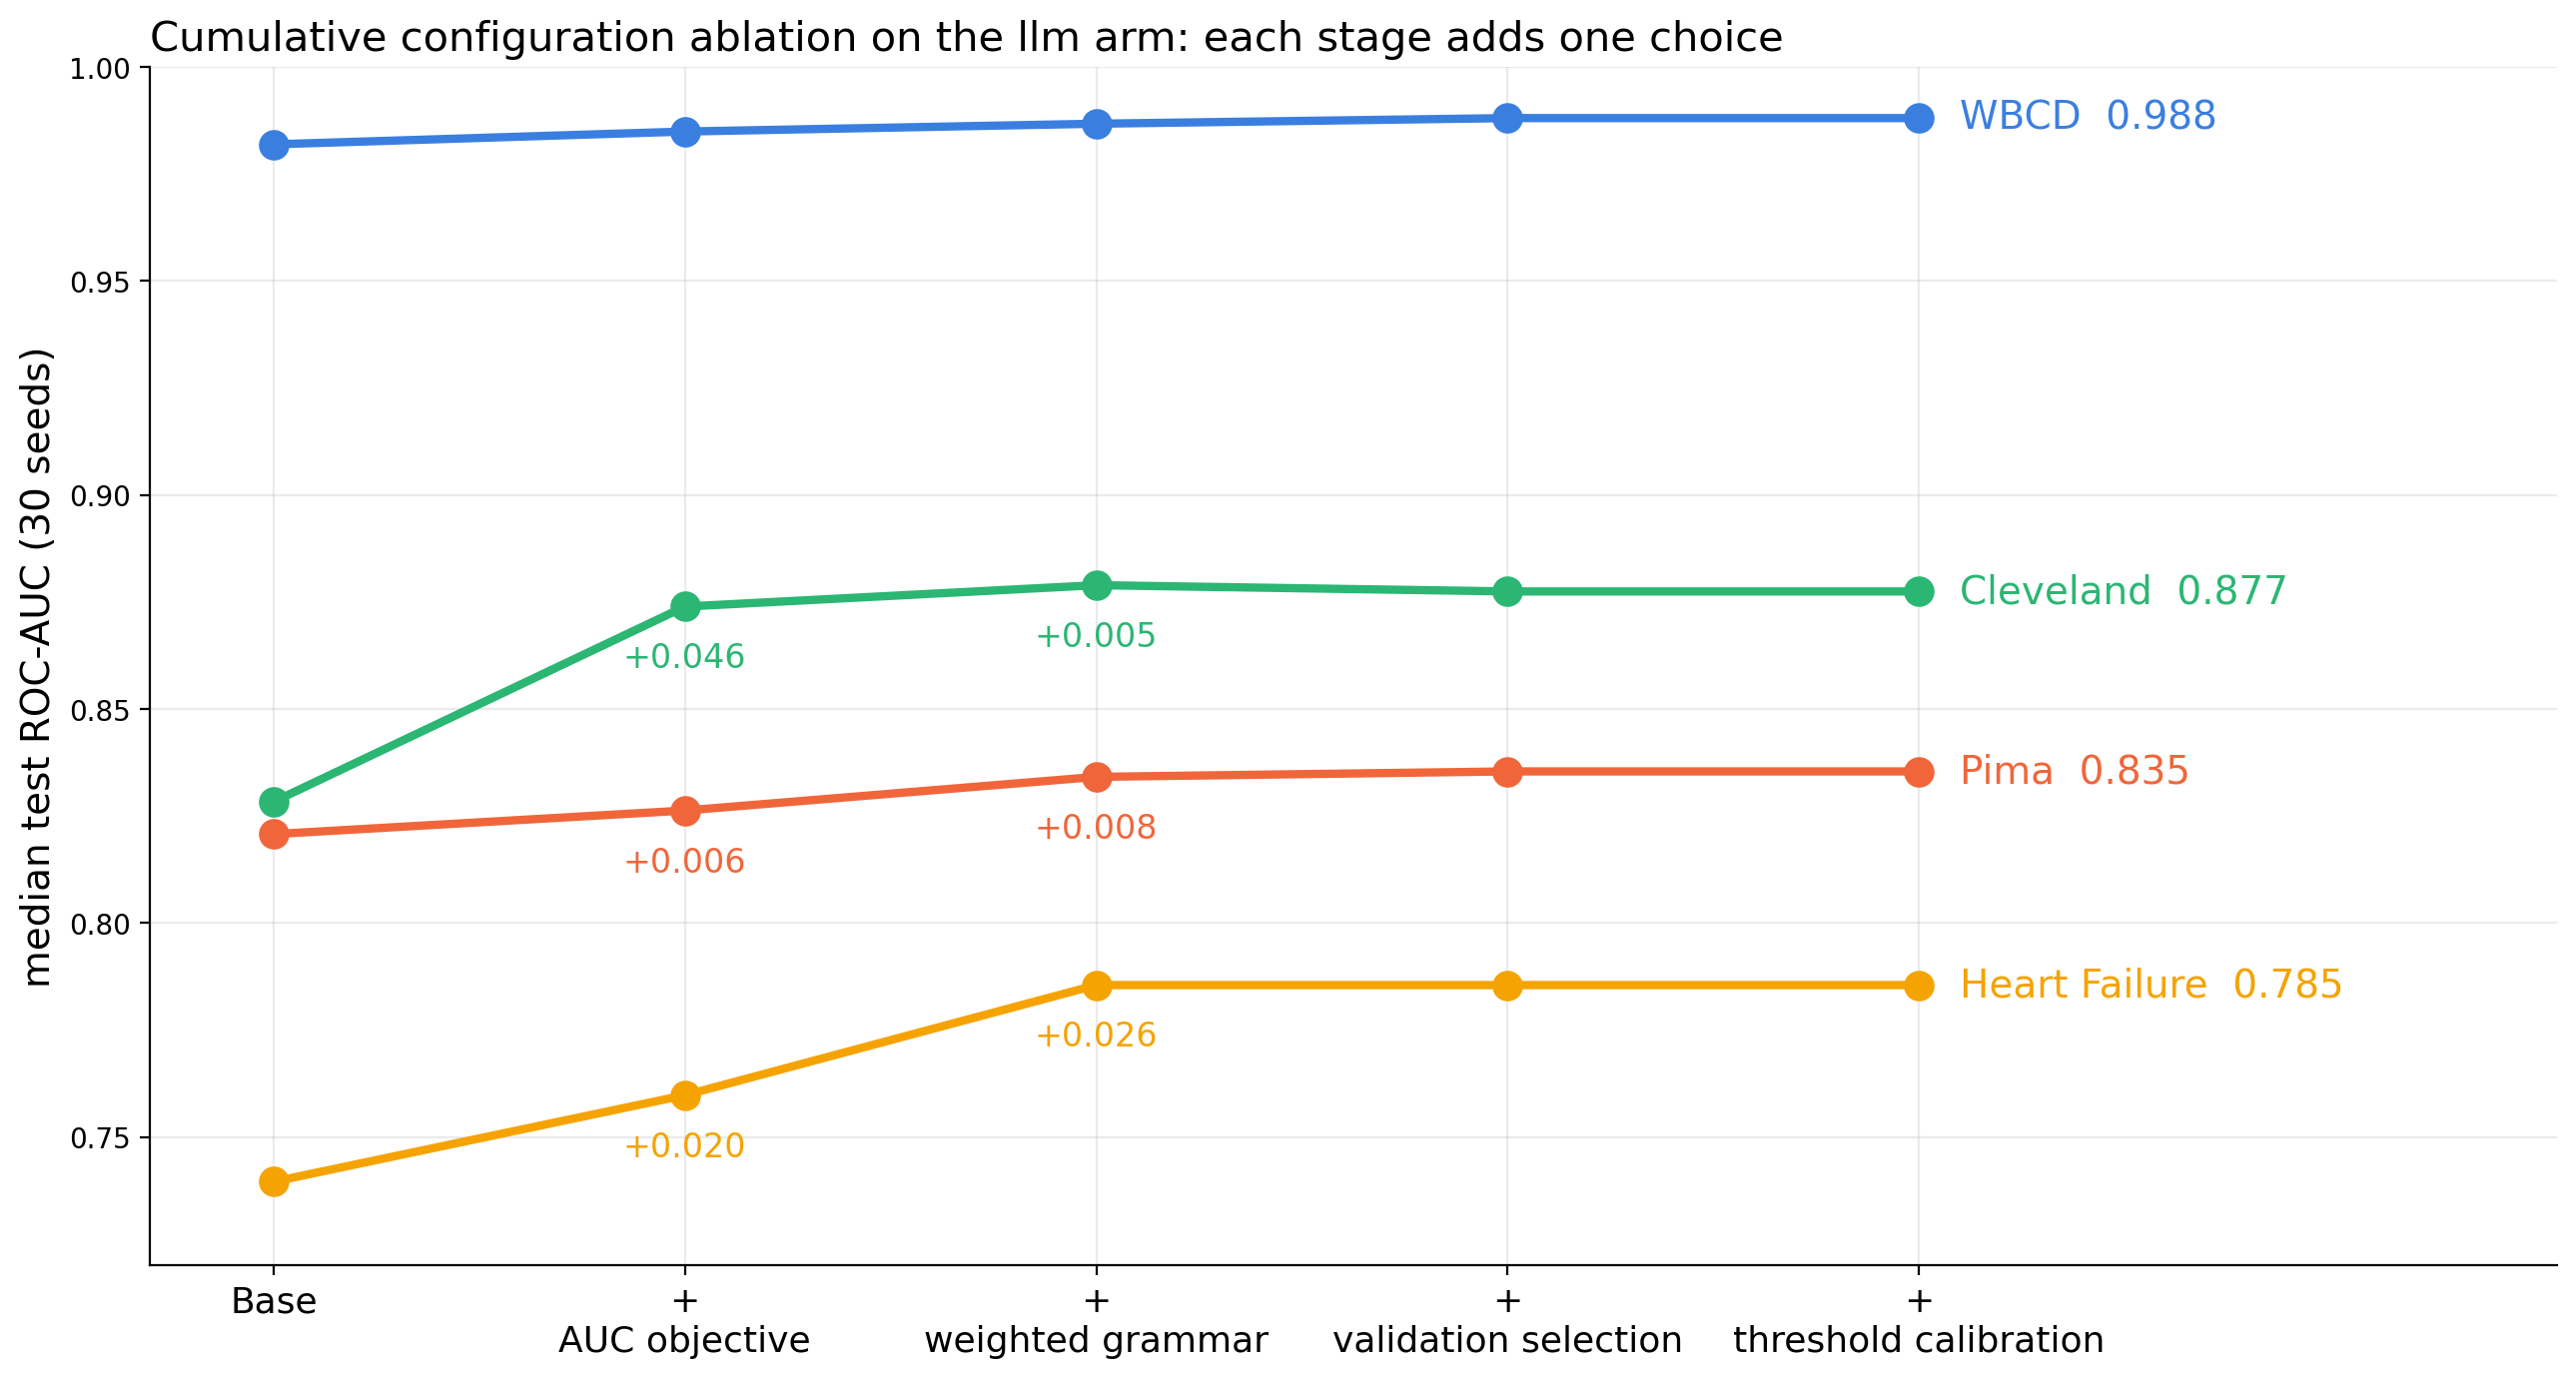

attribution_channels.png


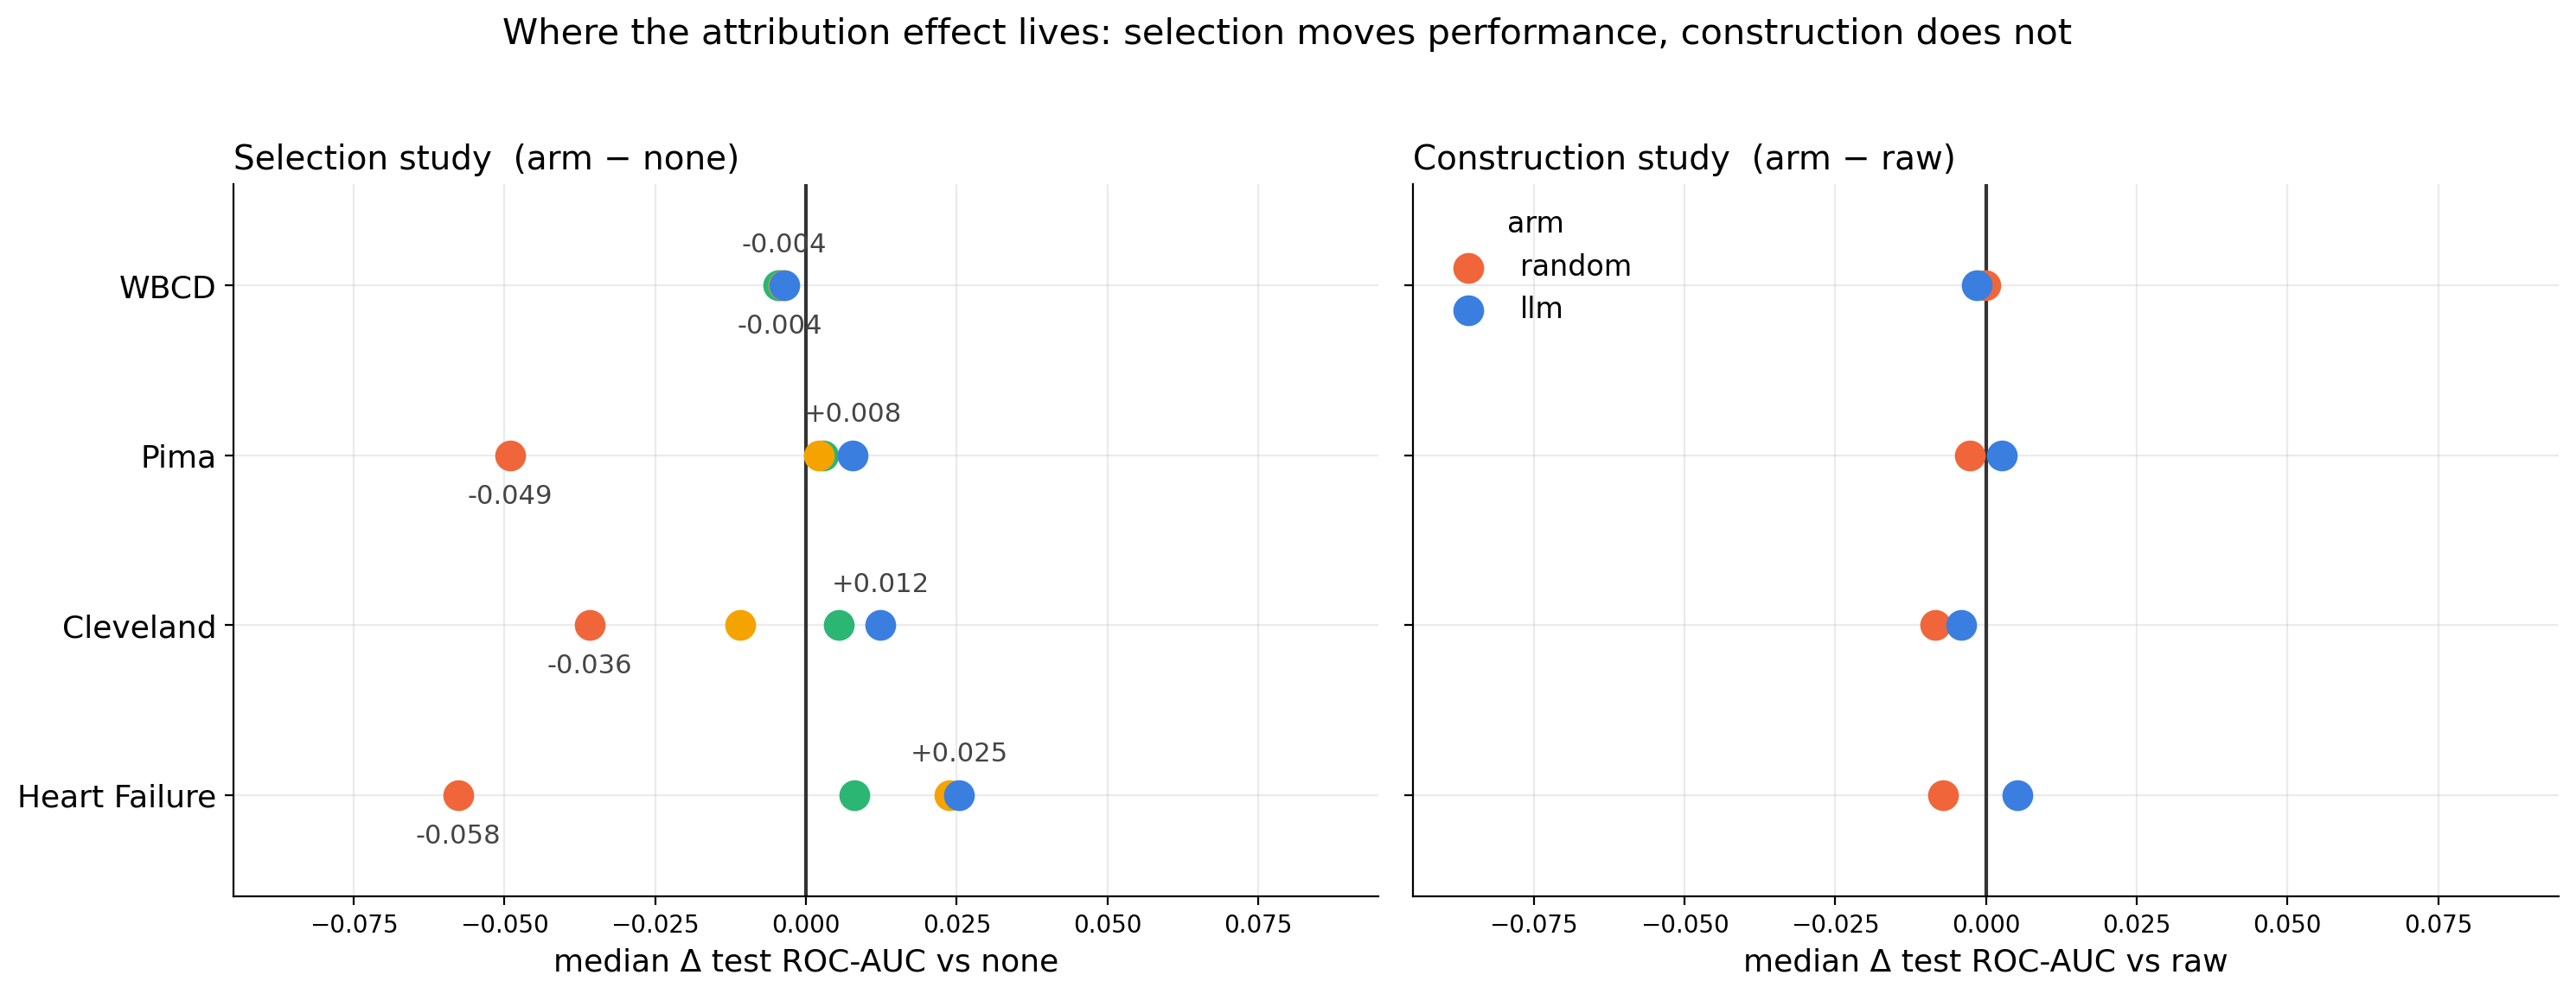

configuration_ablation.png


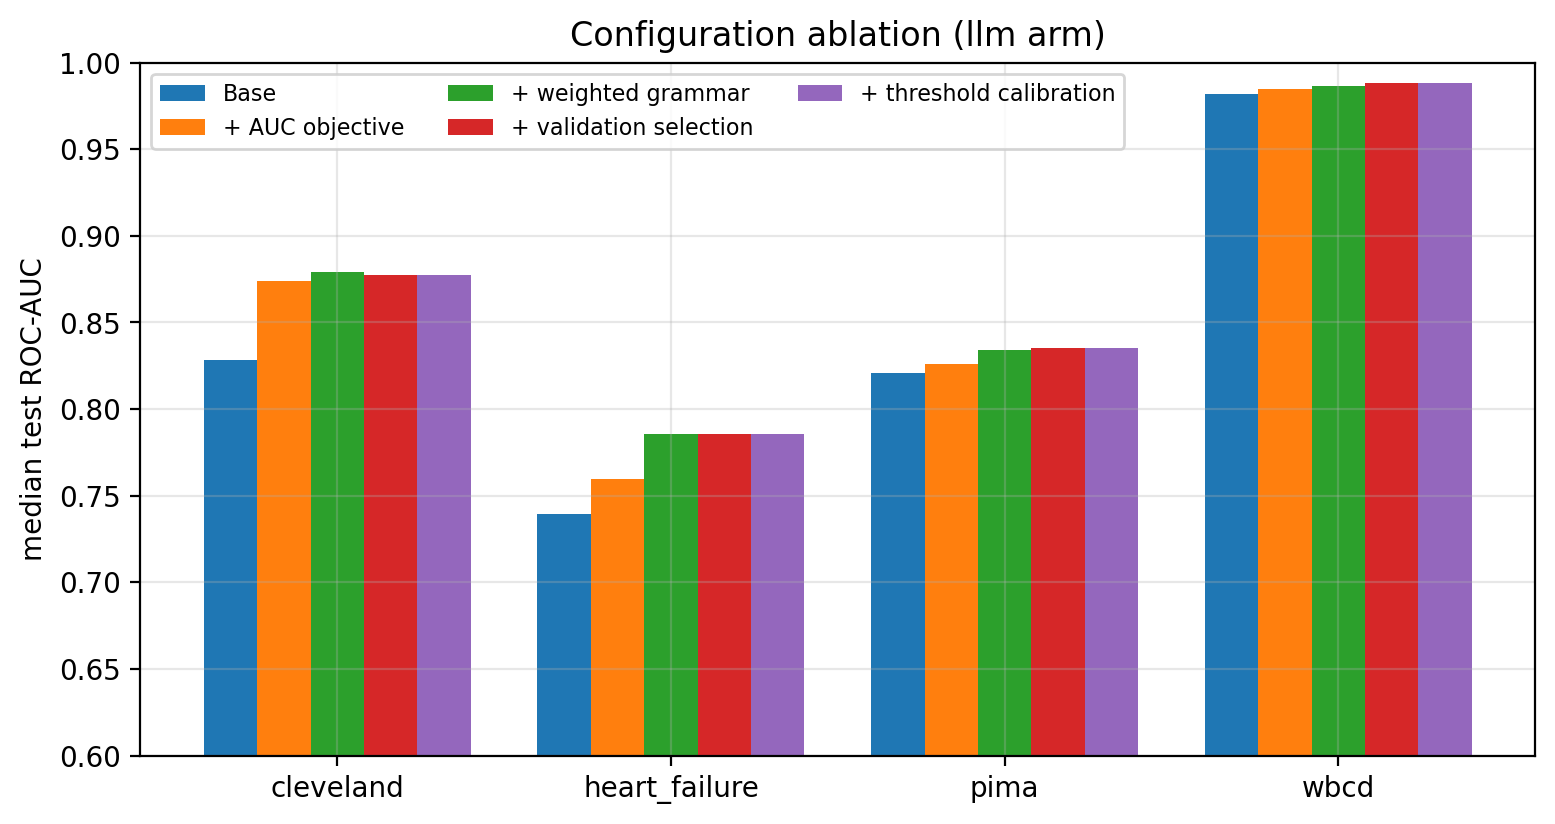

contrast_differences.png


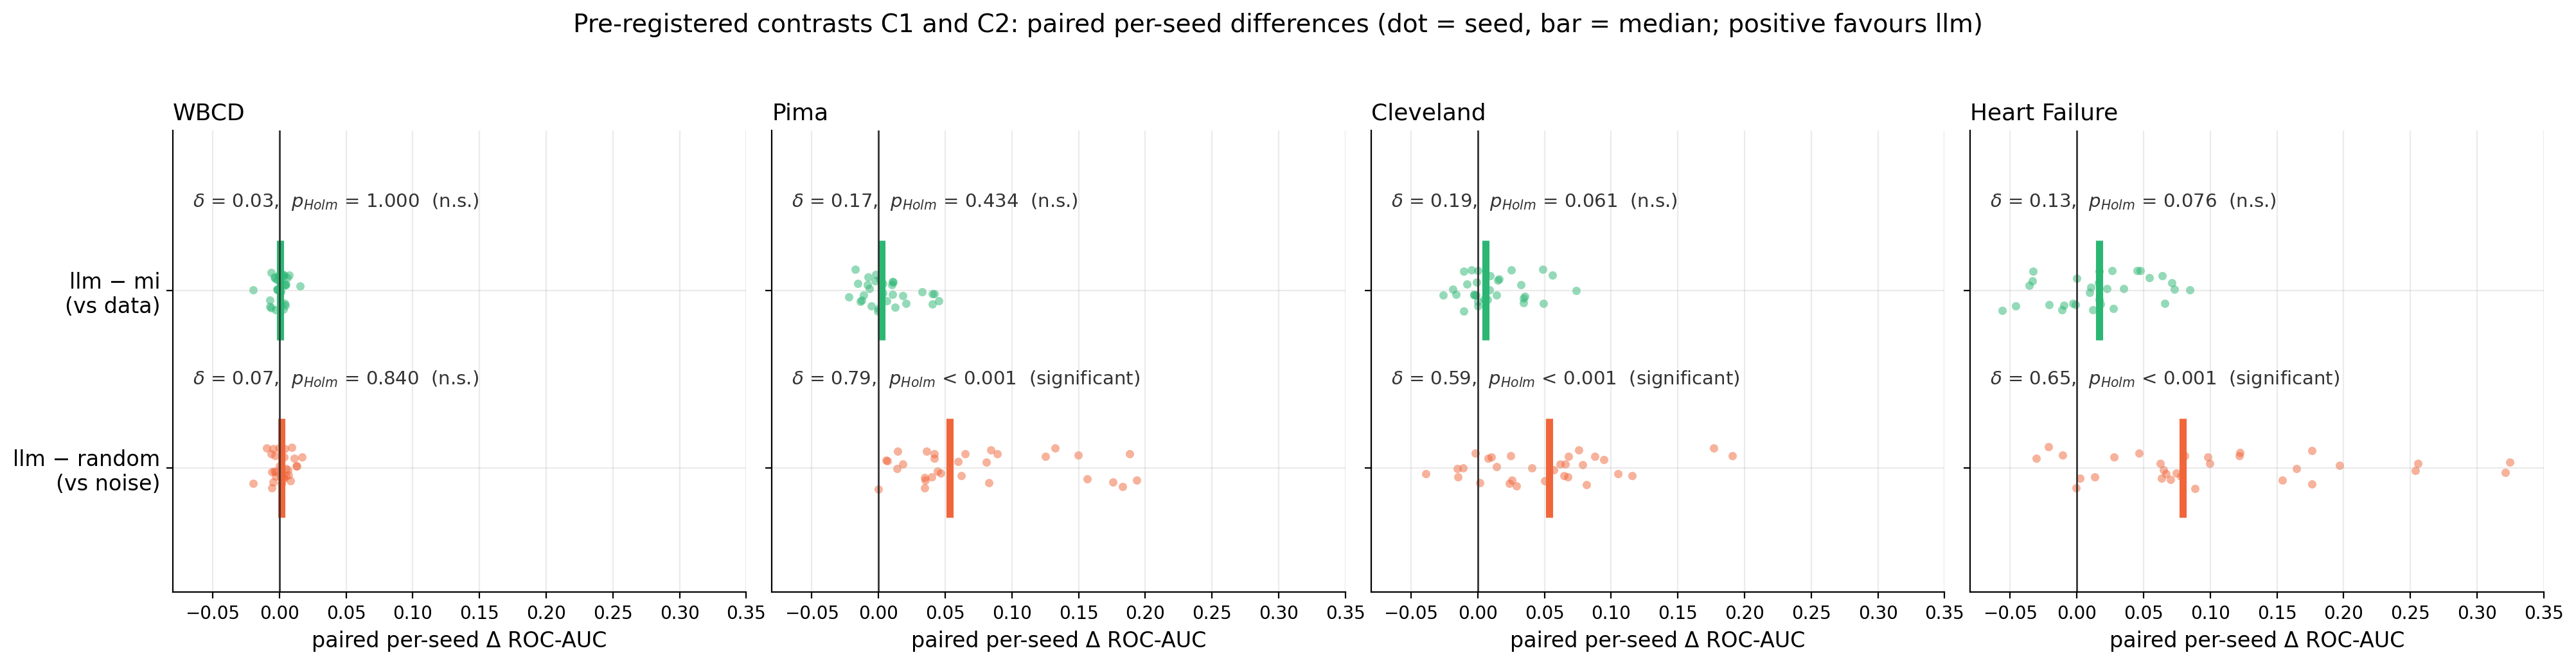

featllm_head_to_head_pima.png


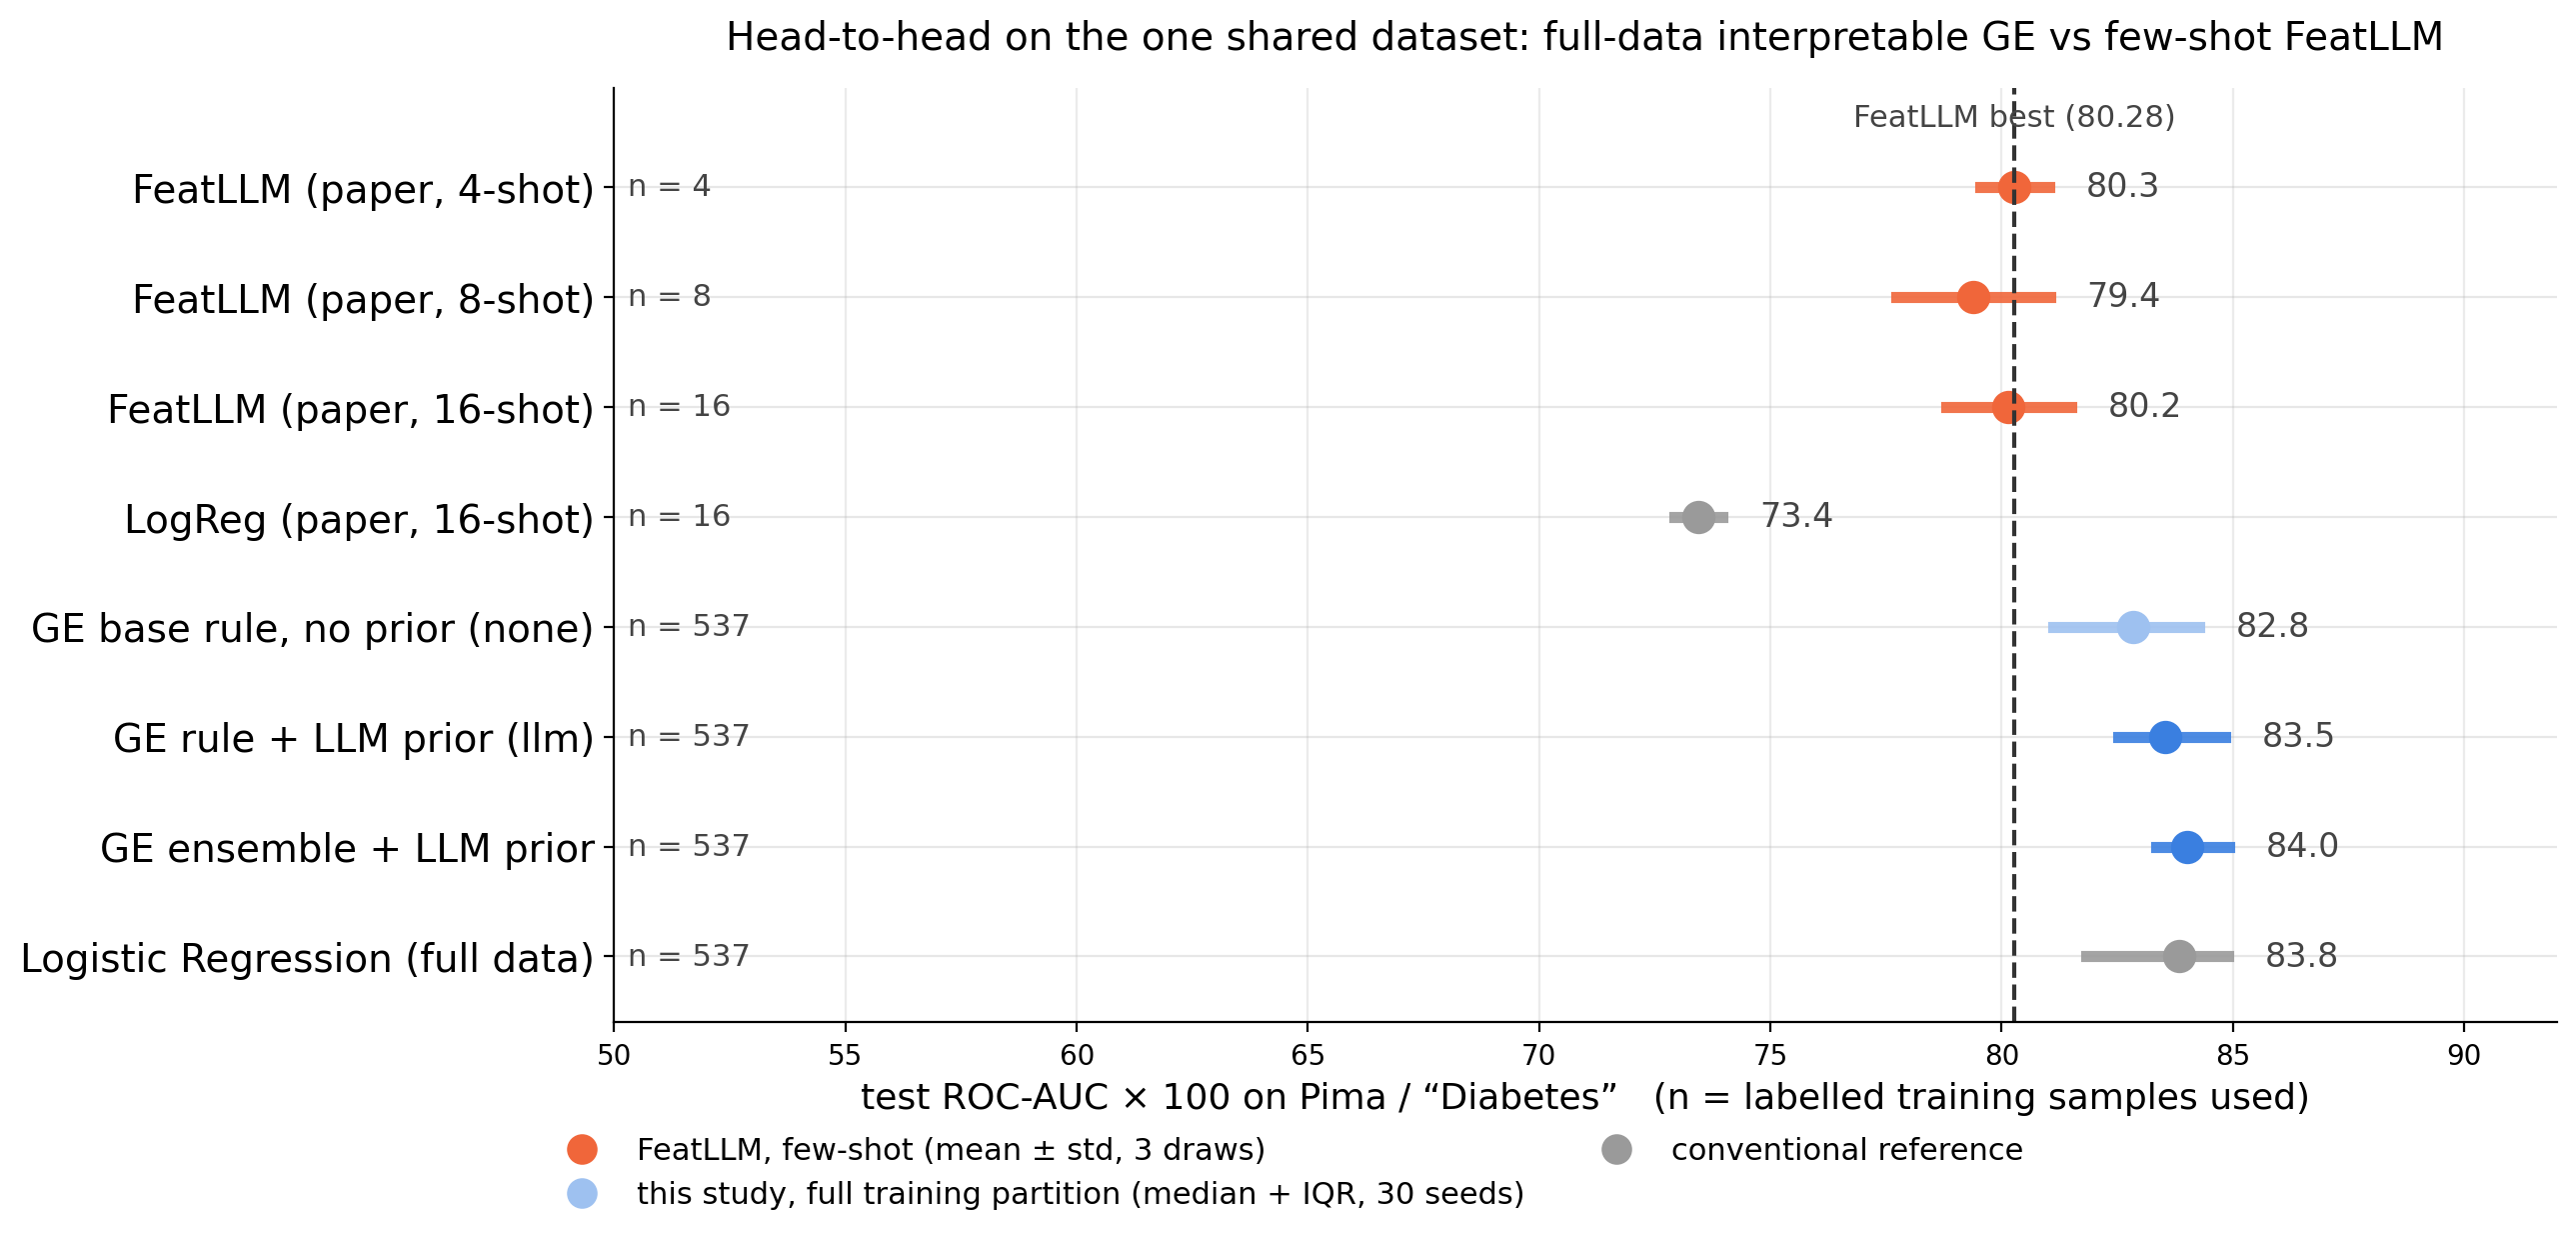

gap_vs_generalisation.png


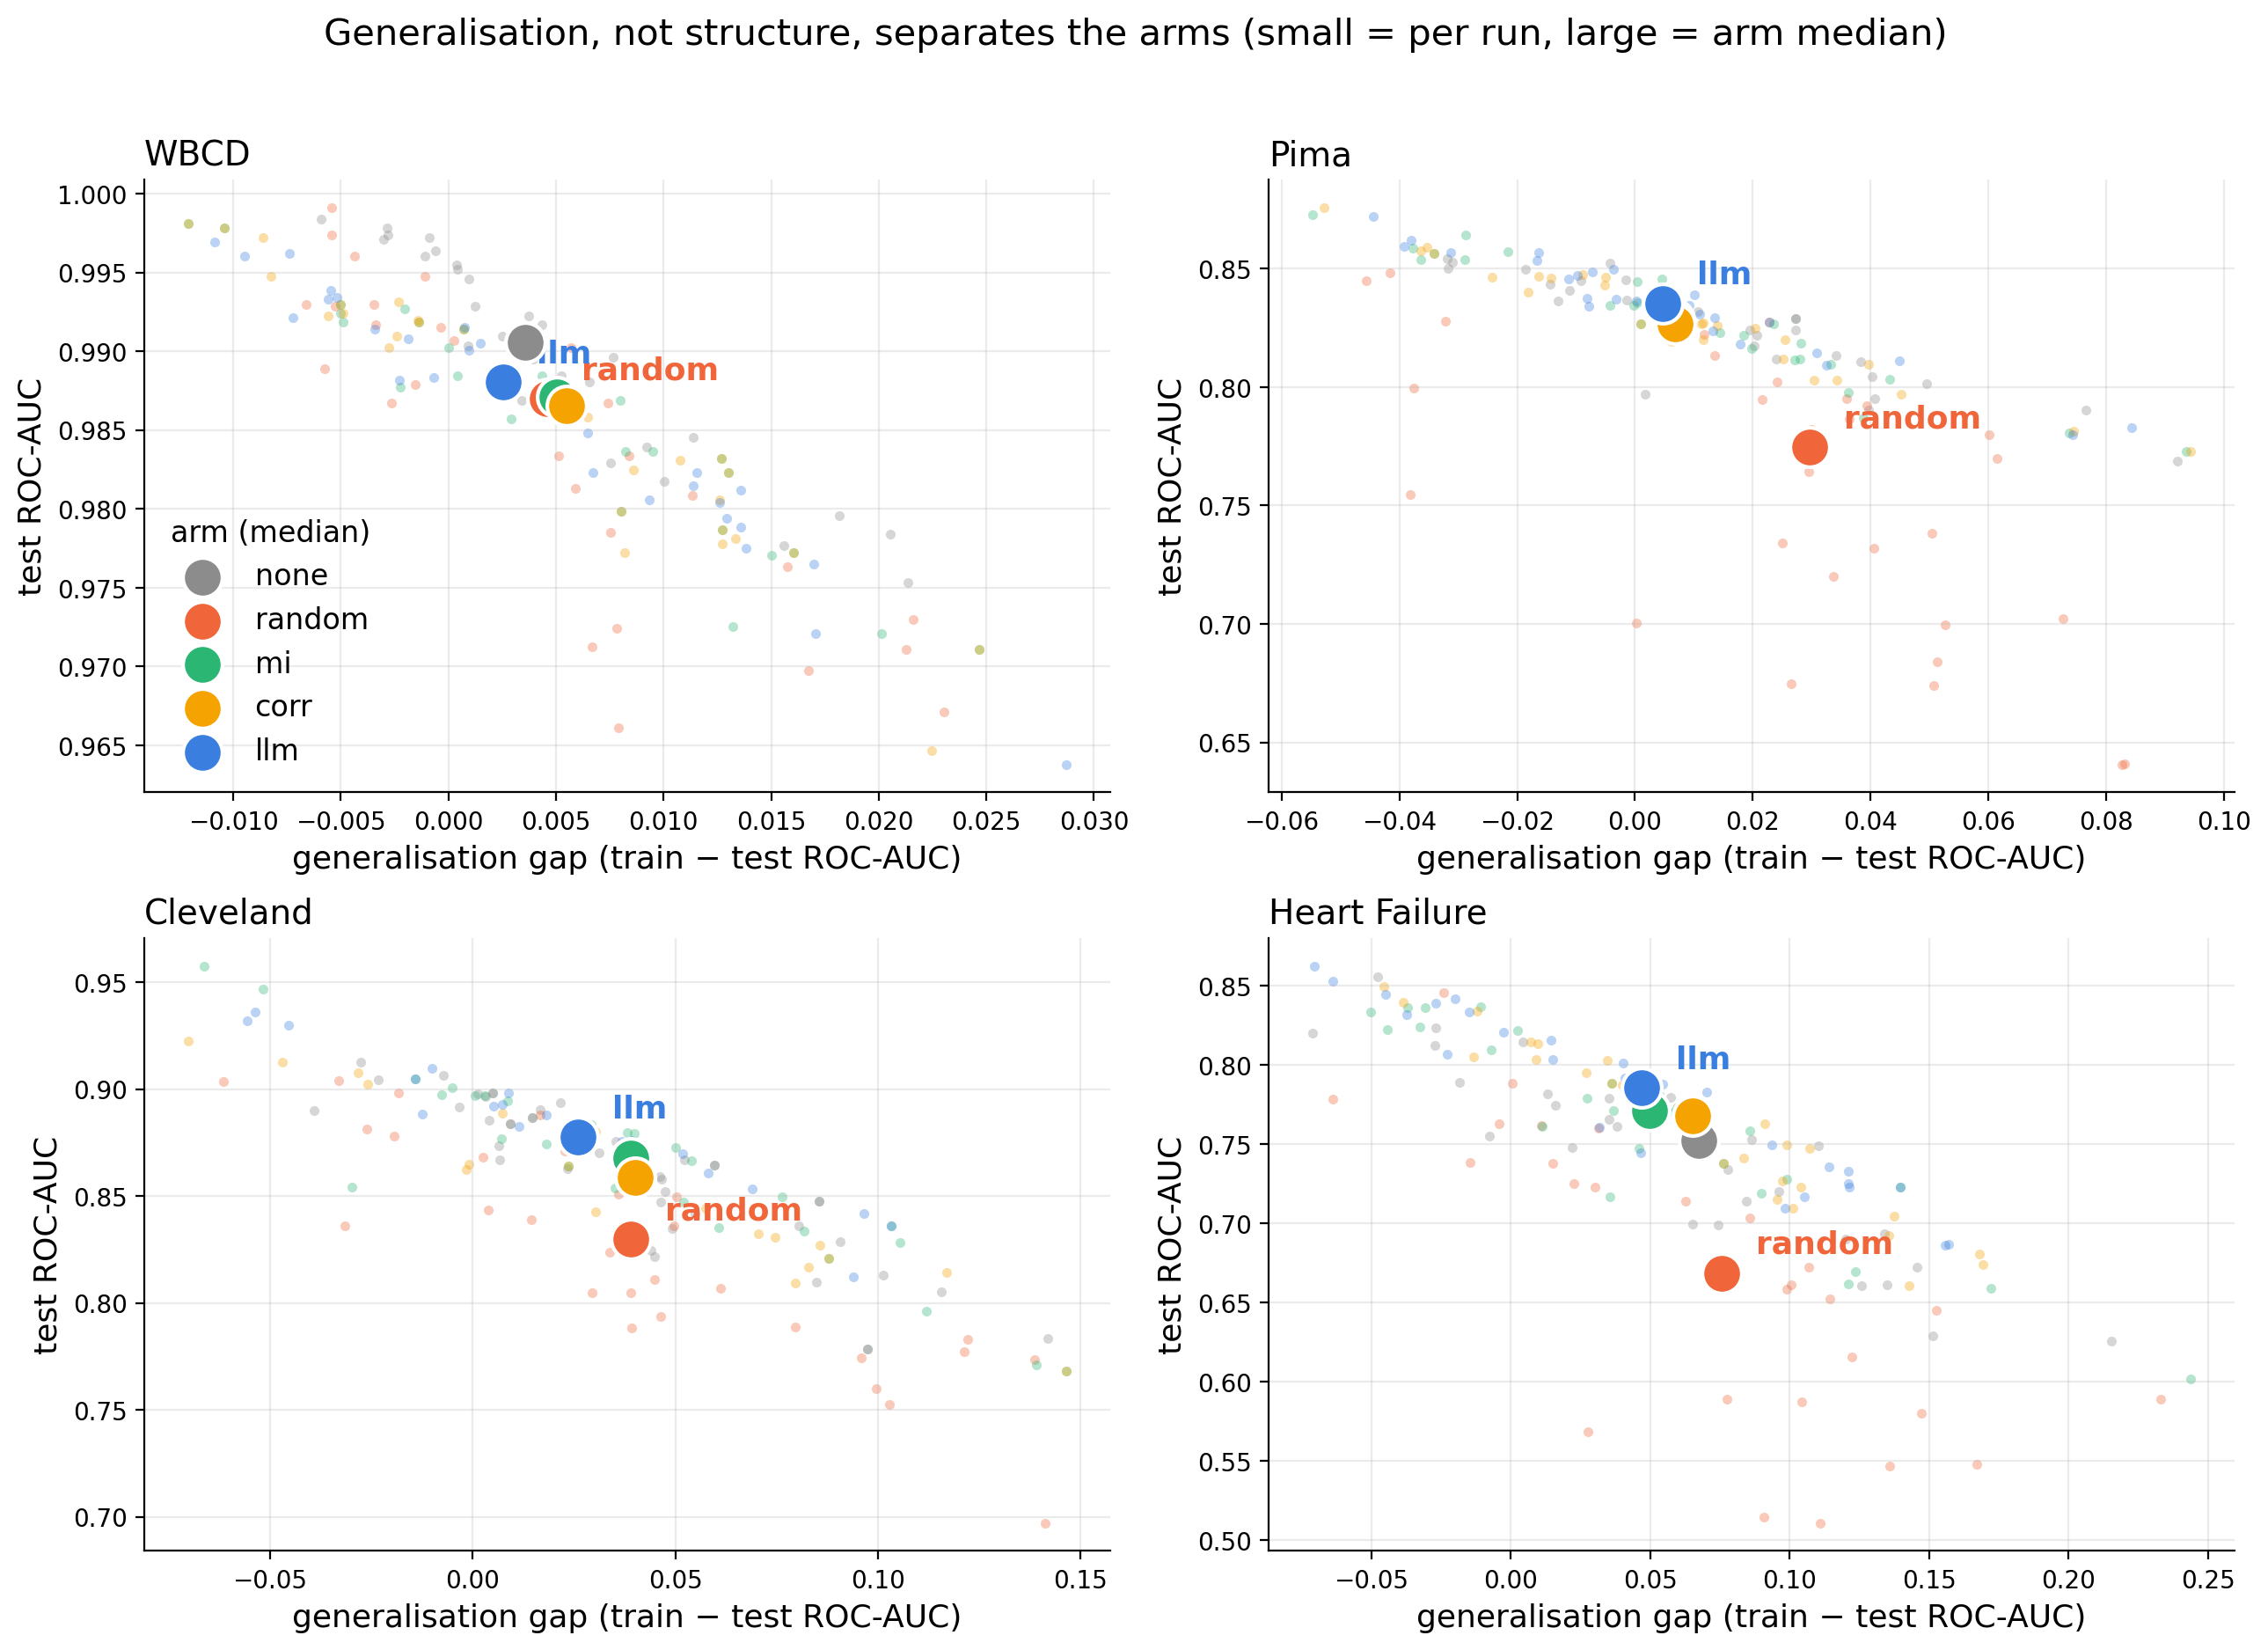

interpretability_cost.png


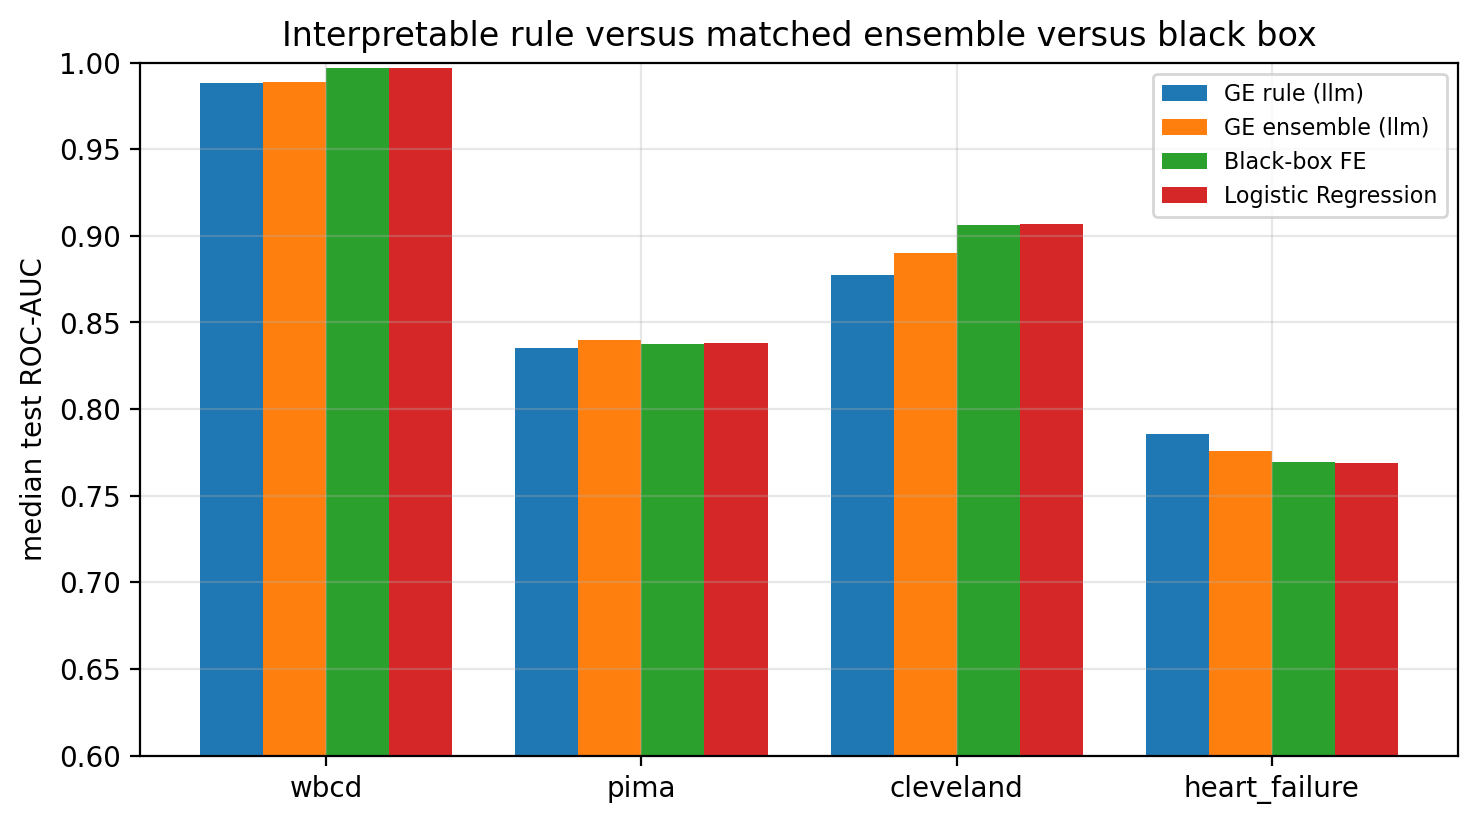

interpretability_cost_iqr.png


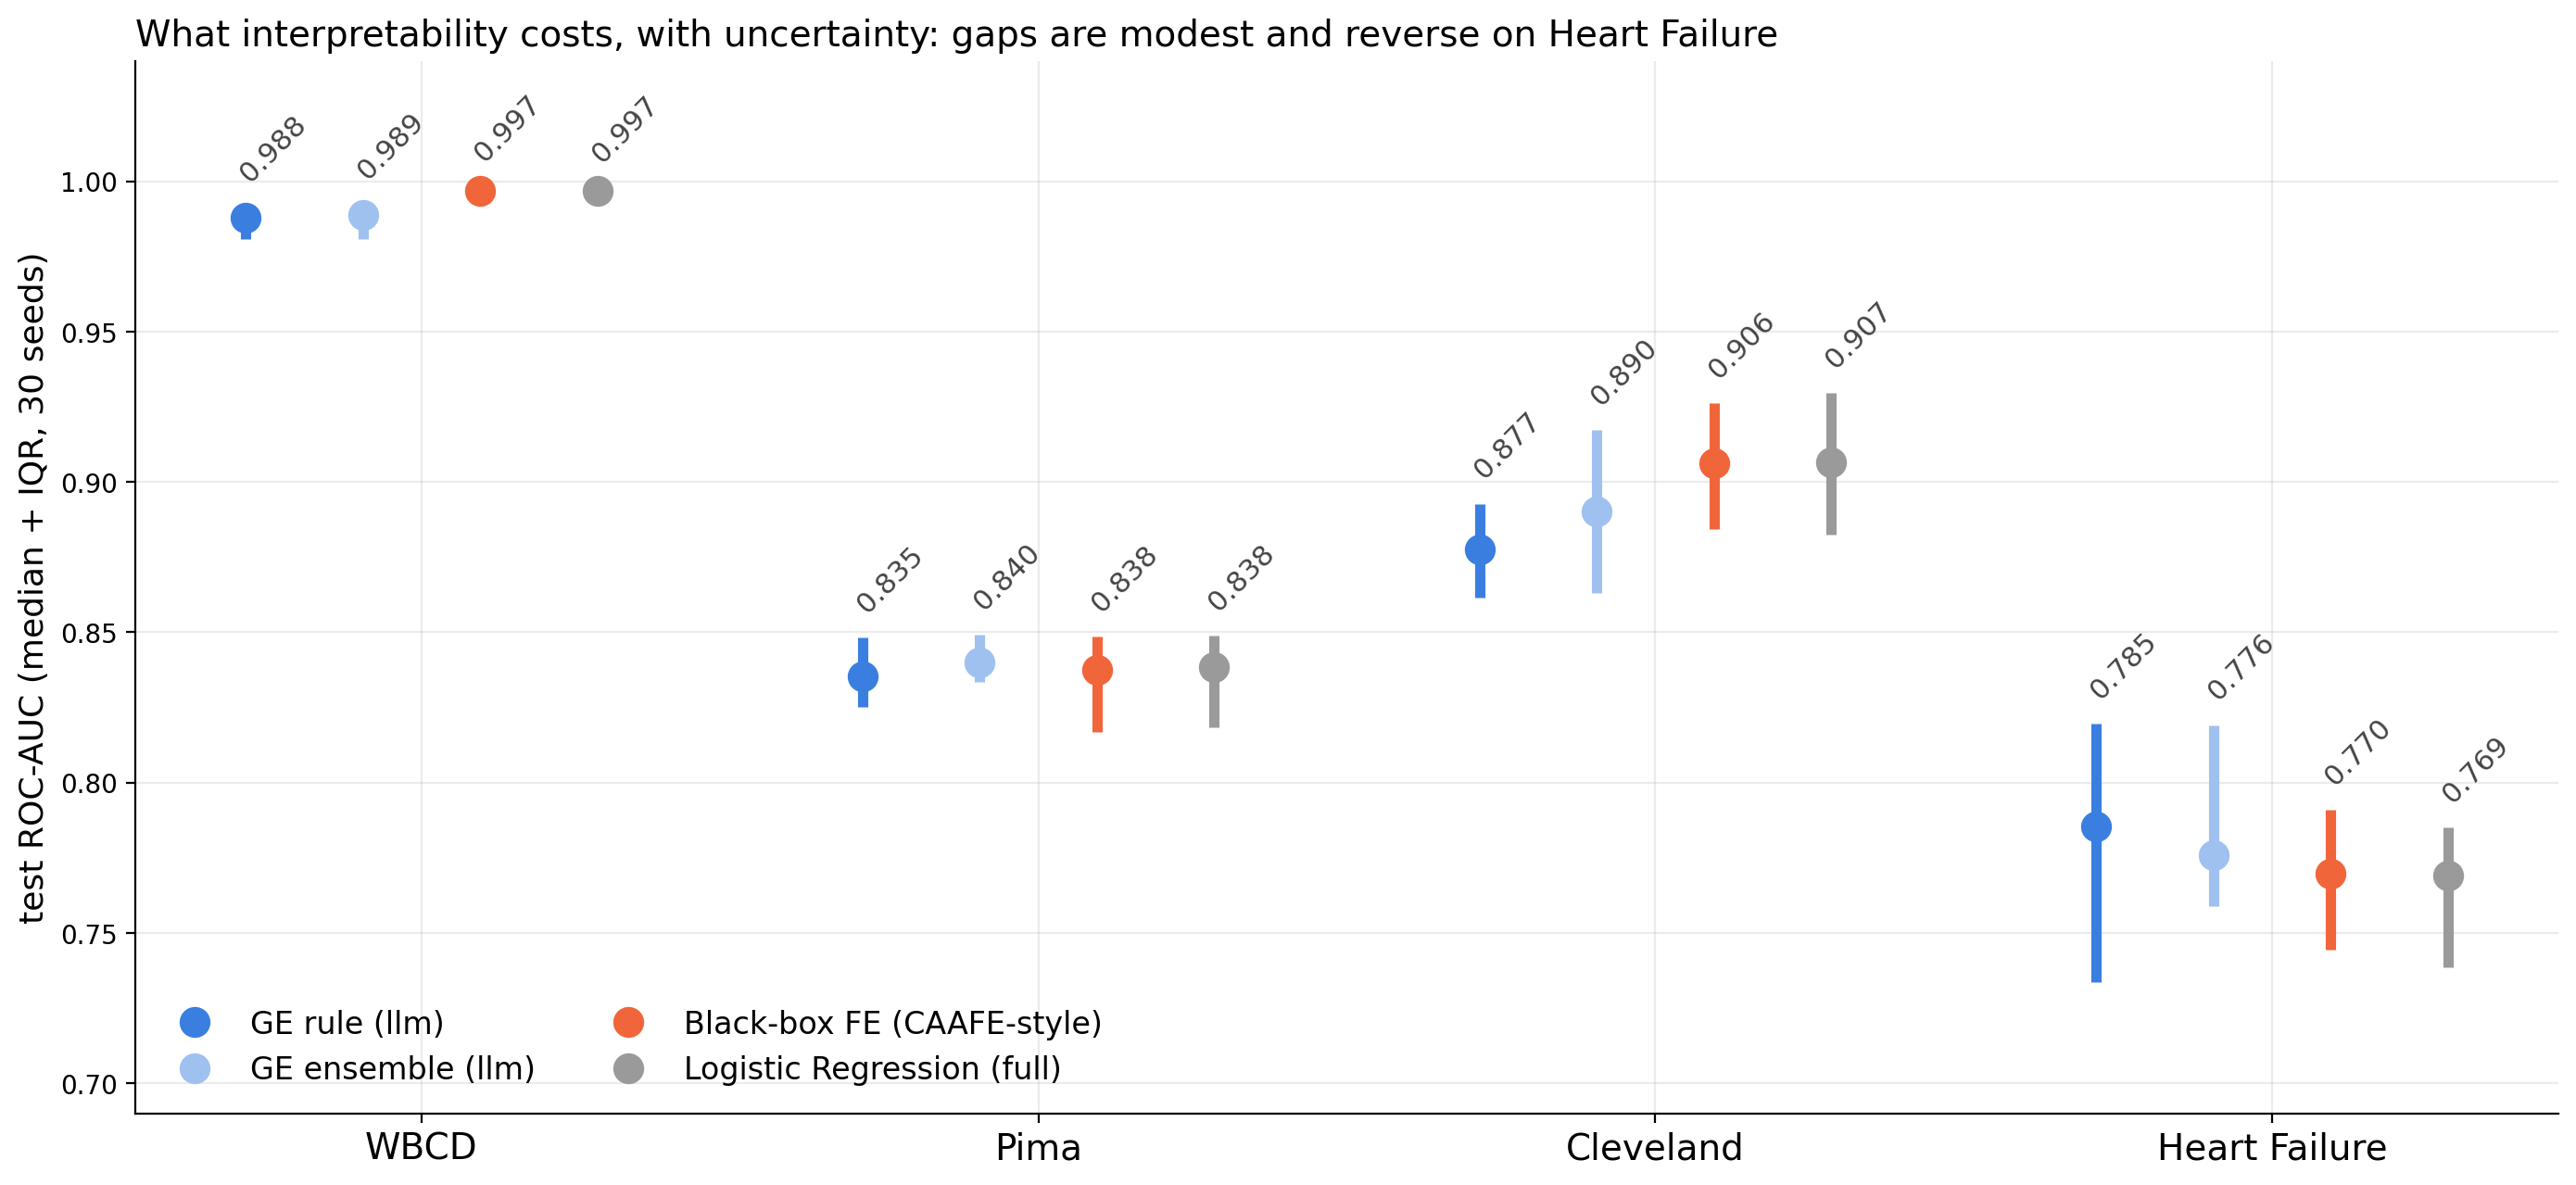

length_vs_generalisation.png


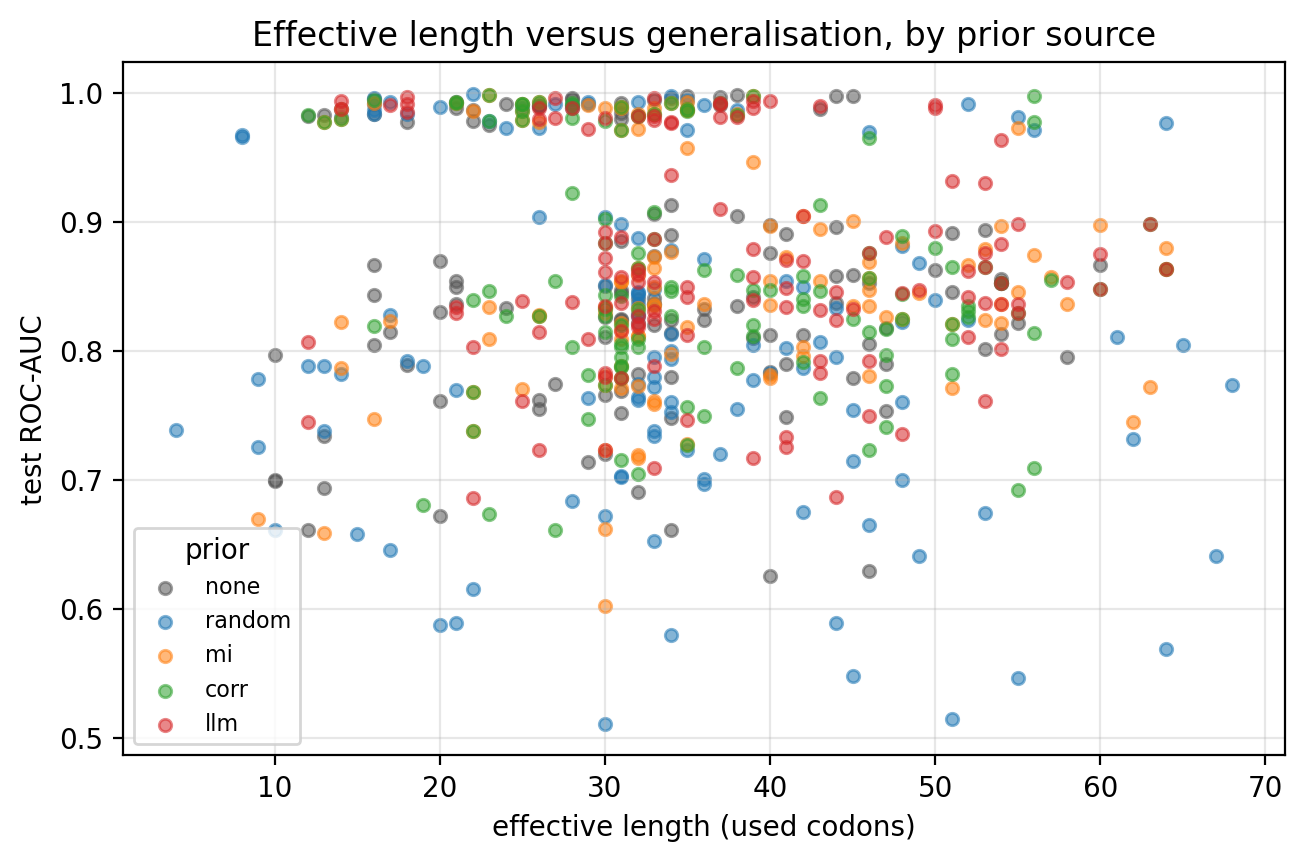

pipeline_anchor.png


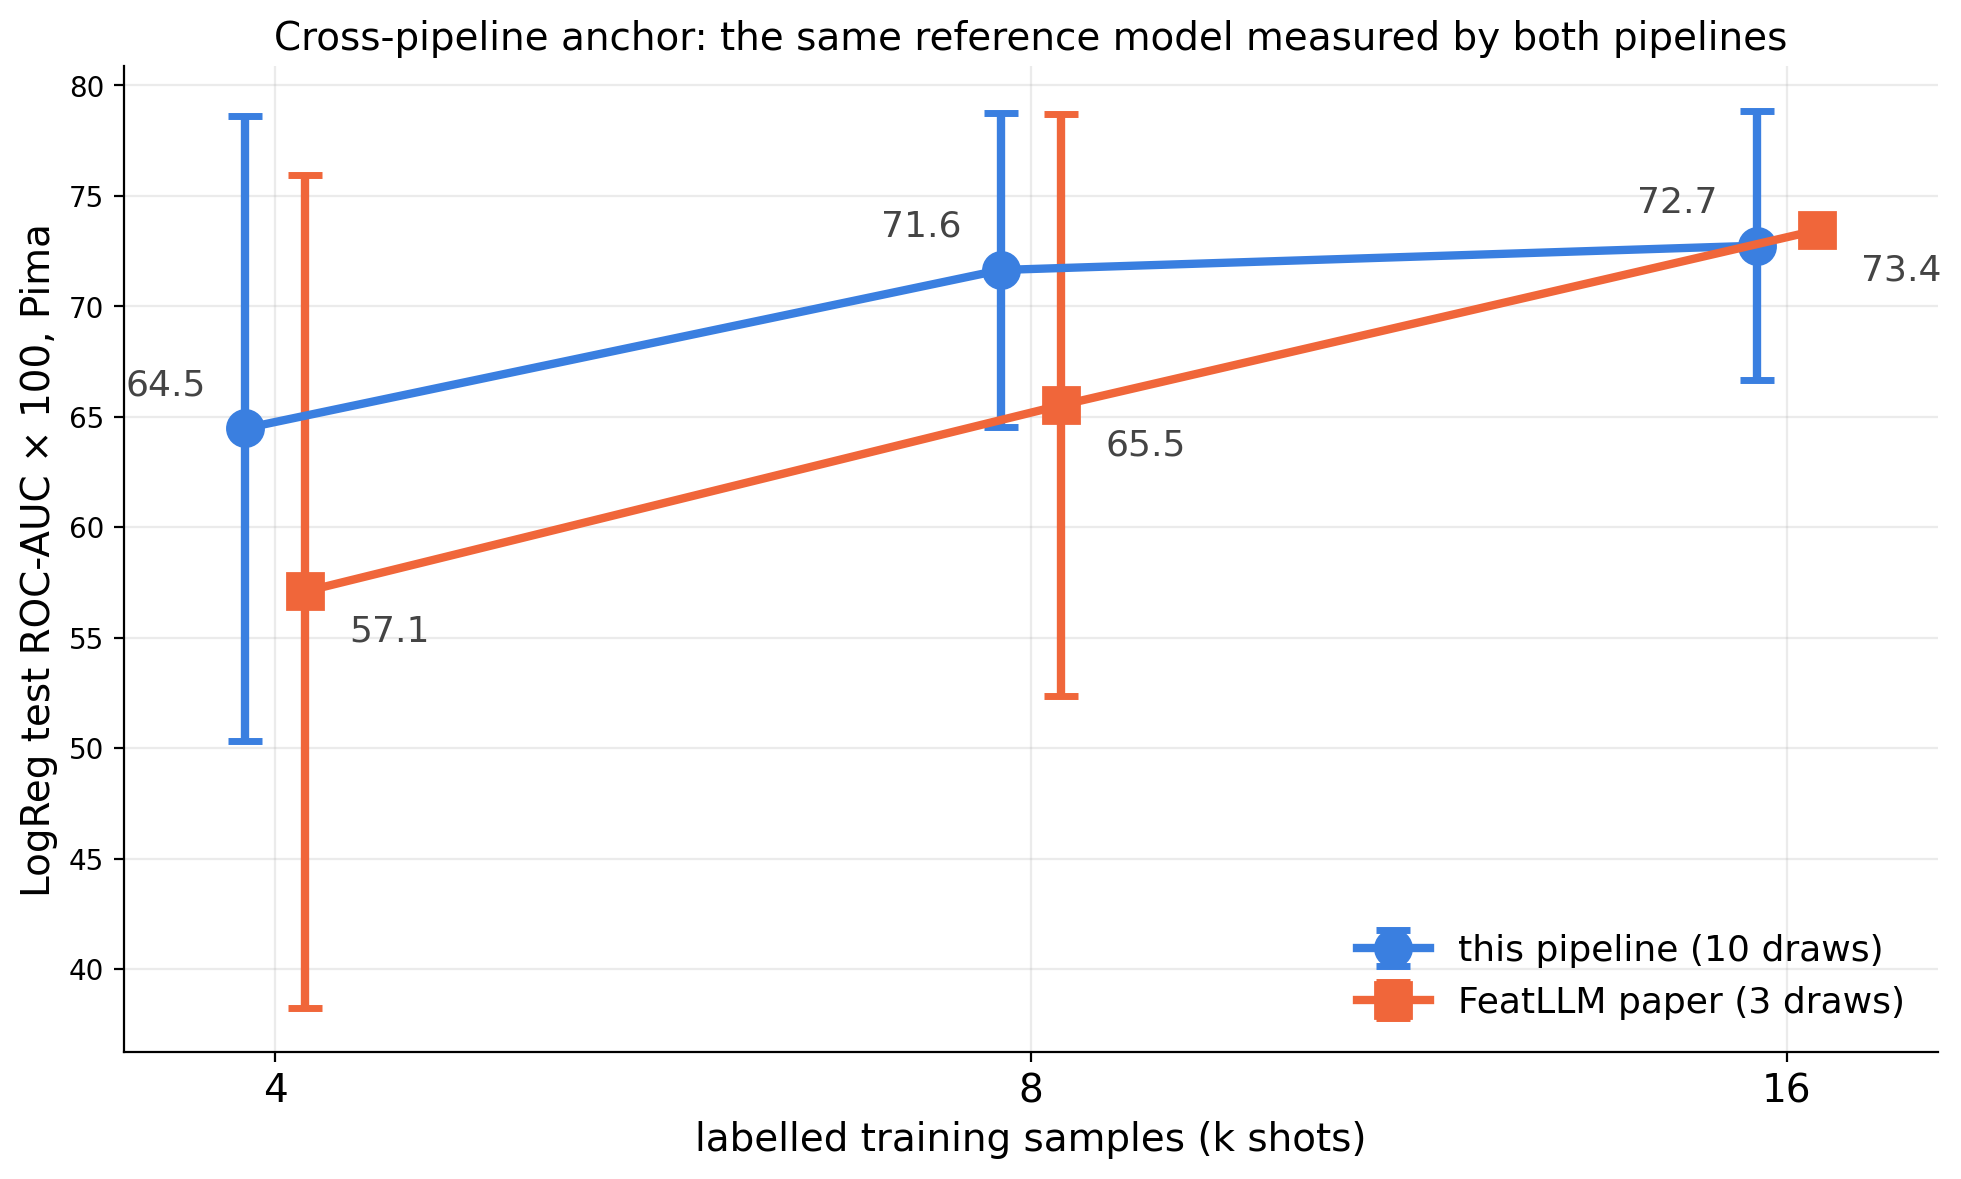

rank_heatmap.png


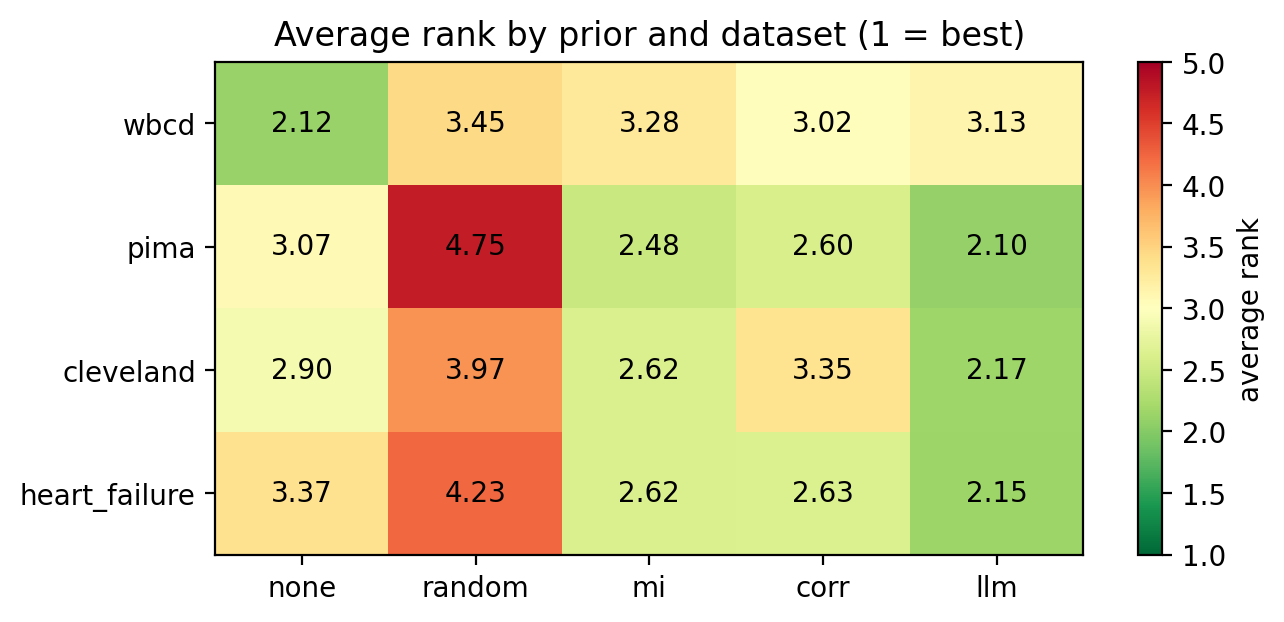

selection_by_dataset.png


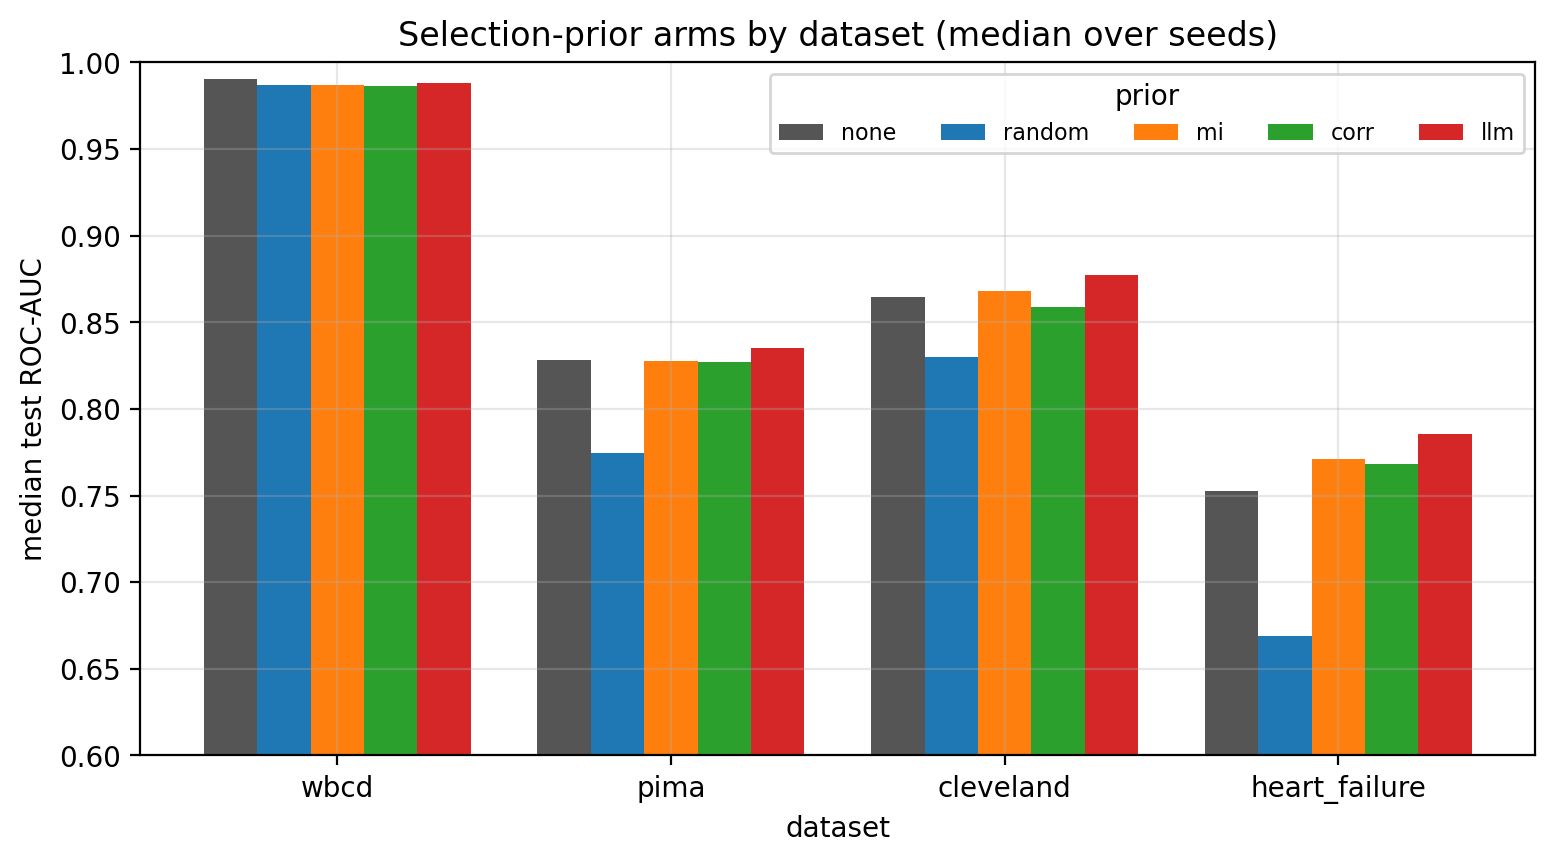

selection_distributions.png


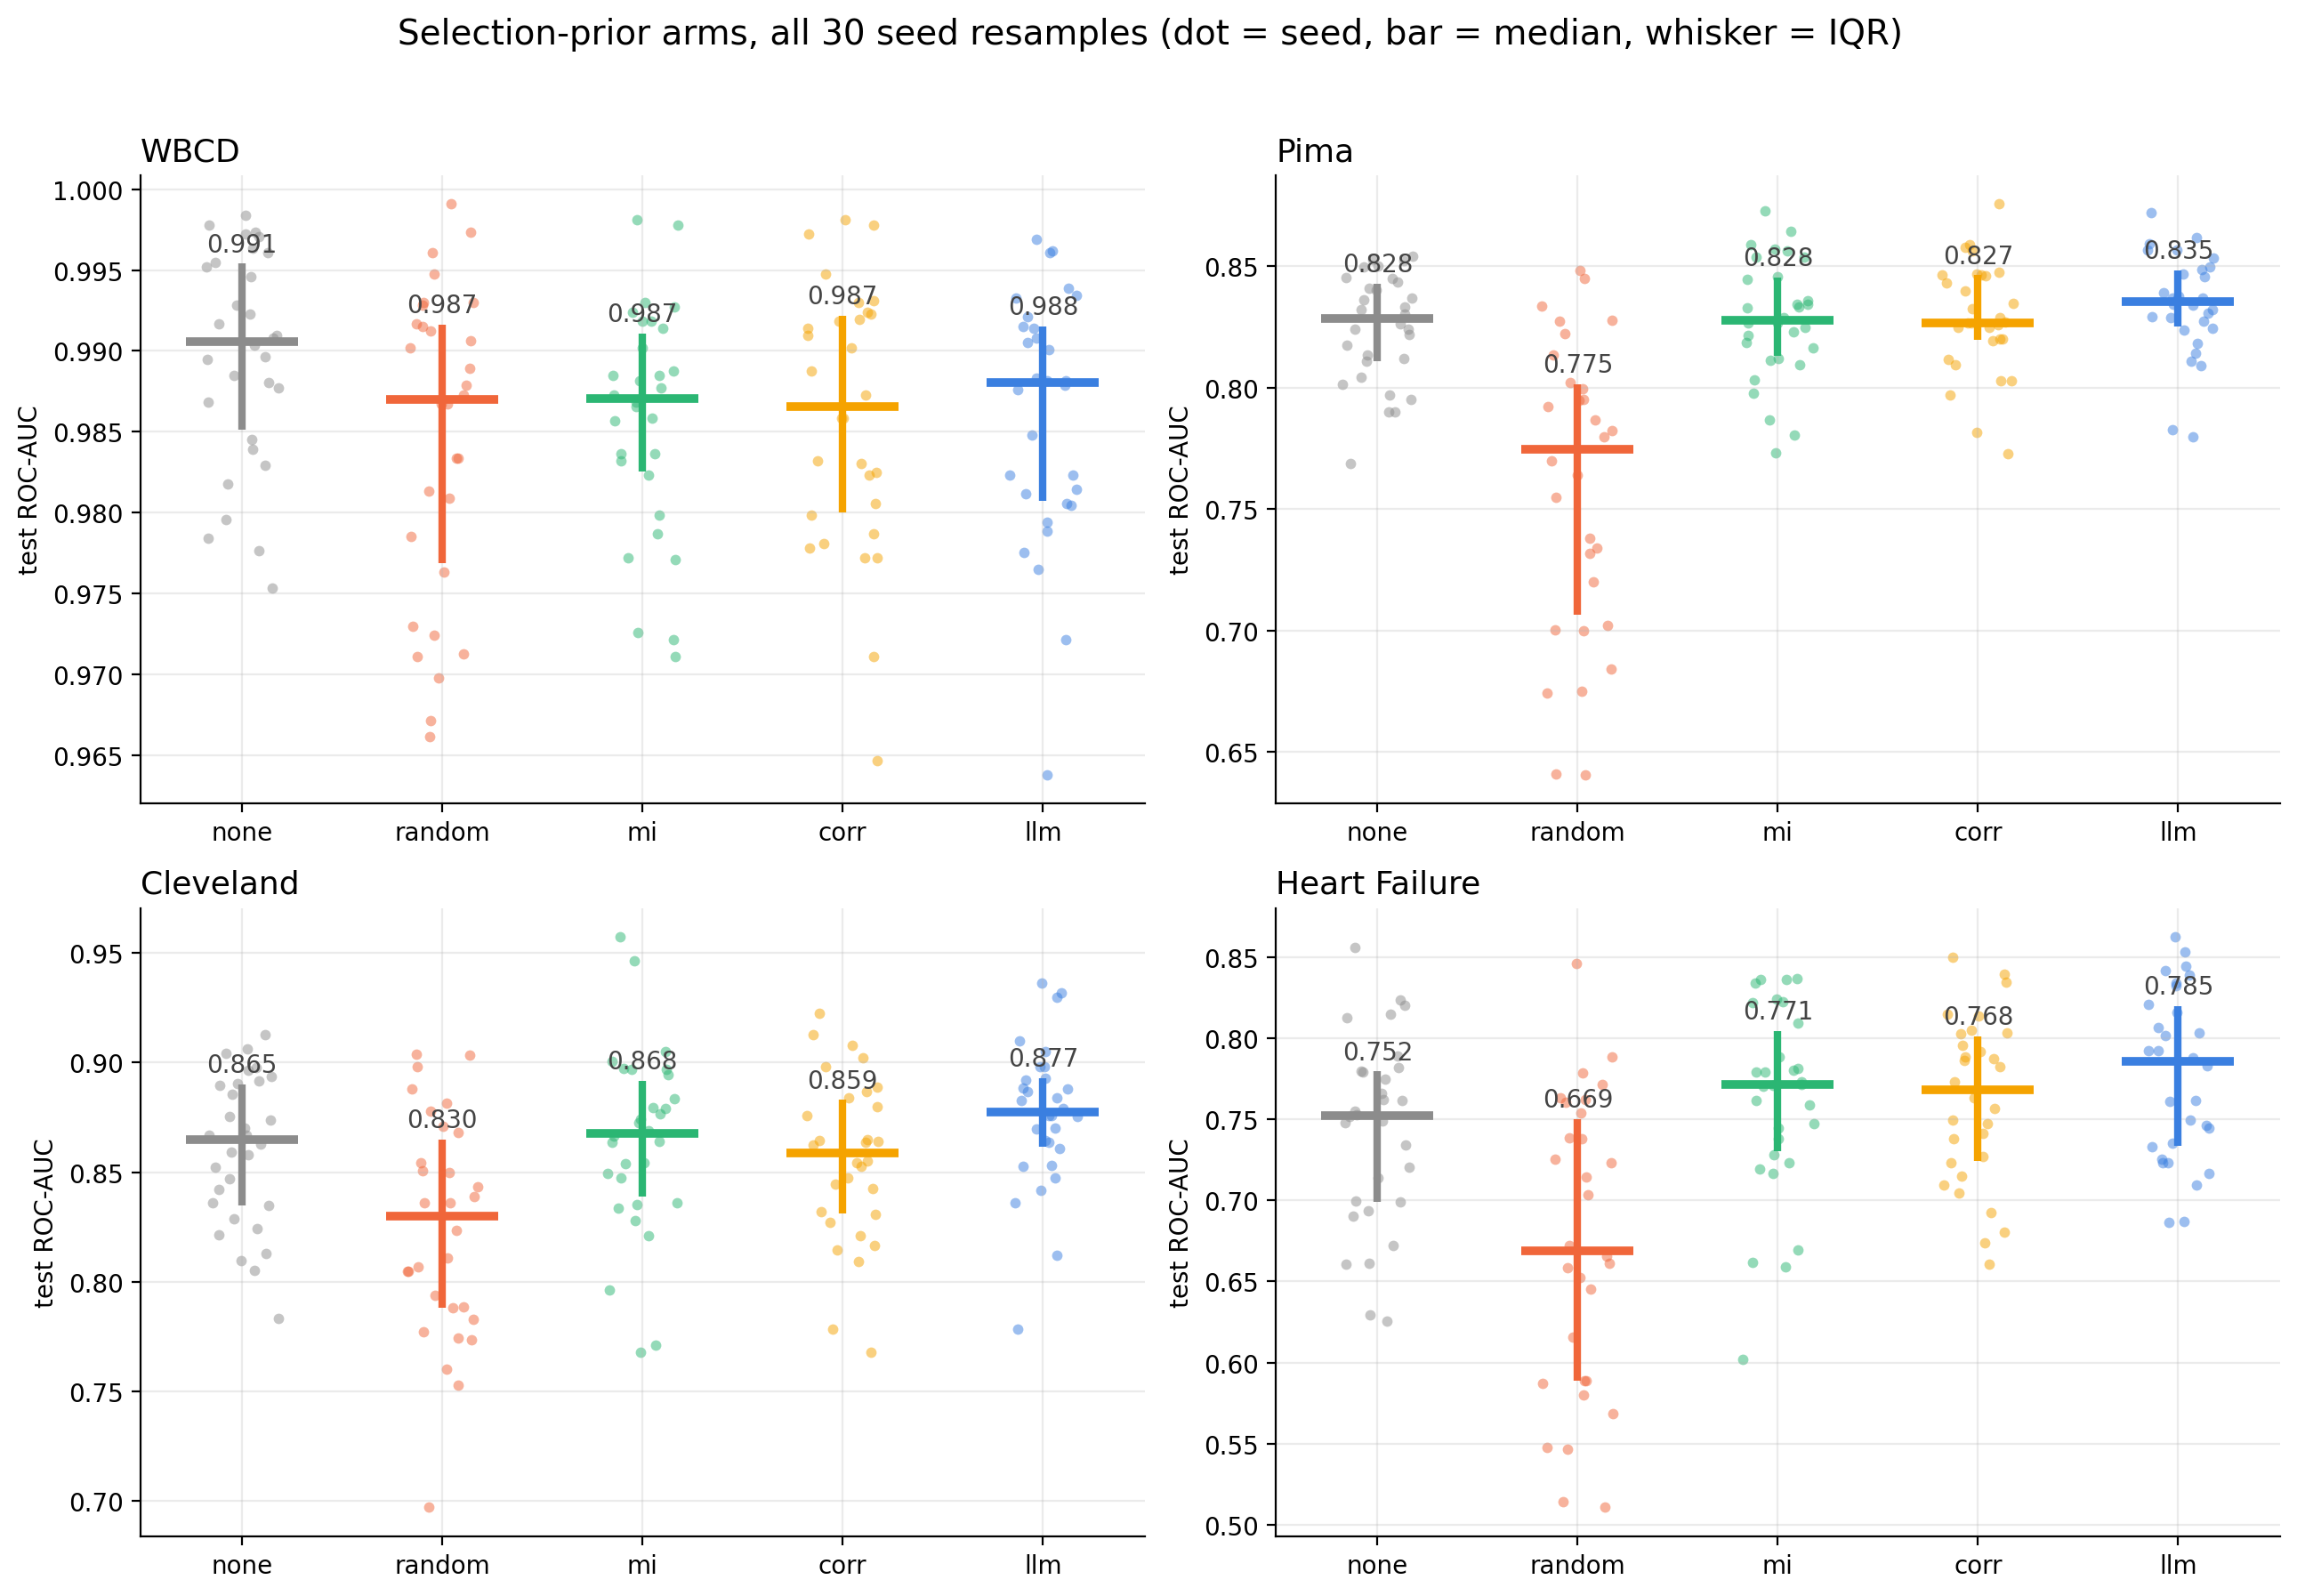

wbcd_confusion.png


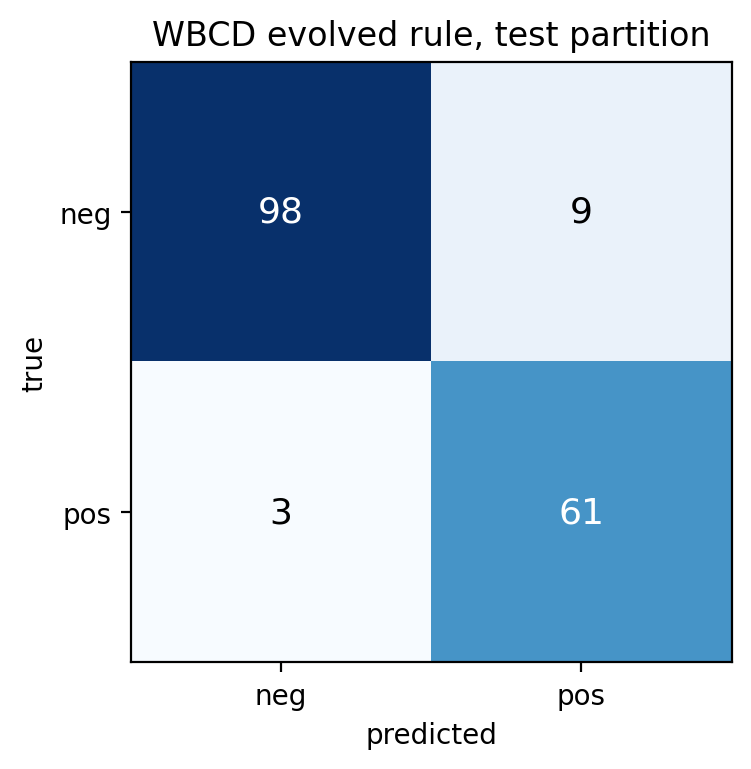

In [22]:
# show every figure of this run inline
from IPython.display import Image
for png in sorted((run.folder / "plots").glob("*.png")):
    print(png.name); display(Image(filename=str(png), width=900))